# Notebook 02: Feature Engineering

## Project: Two Tower Hybrid Model Movie Recommendation

### Purpose of This Notebook

Feature engineering is where we transform raw data into the signals that our models can learn from. This is arguably the most critical step in the pipeline - the quality of features directly determines the ceiling of model performance. No model architecture can compensate for poorly engineered features.

### What we will build in this notebook:

1. **Temporal Split** - Divide data into train/val/test using time-based cutoffs (not random) to simulate real production deployment
2. **Implicit Feedback Conversion** - Transform explicit ratings into binary positive/negative signals for the retrieval stage
3. **User Features** - Aggregate each user's history into a fixed-size feature vector for the User Tower
4. **Item Features** - Encode movie metadata (genres, genome, release year) into dense representations for the Item Tower
5. **Interaction Features** - Create pairwise user-item features for the XGBoost ranking stage
6. **Negative Sampling** - Generate training examples where user did NOT interact with an item (critical for learning "what to avoid")

### Connection to the Architecture

```
  OFFLINE (after training - Notebook 03)      ONLINE (at inference time - Notebook 06)
  ======================================      ==========================================
  
  Item Tower produces embedding               Known user request arrives
  for EVERY movie in catalog                       |
       |                                           v
       v                                      Look up pre-computed user_embedding (64-dim)
  Store item embeddings in FAISS              from Embedding KV (Redis/DynamoDB in prod)
  (Milvus/Pinecone in prod)                        |
       |                                           v
  User Tower produces embedding               [FAISS search] --> top-100 movie IDs
  for EVERY known user                             |
       |                                           v
       v                                      Look up user_features + item_features
  Store user embeddings in KV store           from Feature KV (Redis/DynamoDB in prod)
  (Redis/DynamoDB in prod)                         |
       |                                           v
       v                                      Compute interaction features on the fly
  Store user/item features                    (genre_match, popularity_gap, time, etc.)
  in Feature KV store                              |
                                                   v
                                              [XGBoost Ranking] --> top-10
                                              Uses: user feats (24) + item feats (73)
                                                    + interaction feats (7) = 104-dim
```

**Key design points:**
- Both user and item embeddings are pre-computed offline (Notebook 03) and stored. No neural network runs at inference for known users.
- FAISS narrows 21K movies to 100 candidates in <1ms via vector similarity. XGBoost then scores only 100 items with full feature richness.
- The two towers MUST be independent: item embeddings are pre-computed offline without knowing which user will query.

The retrieval stage needs **separate** user and item features (they go into different towers).
The ranking stage can use **all** features including cross-features between user and item.

### Which features feed which model?

| Feature Set | Two-Tower (Retrieval) | XGBoost (Ranking) | Why |
|---|---|---|---|
| User features (24-dim) | YES - User Tower input | YES - user-side features | Both need to understand the user |
| Item features (73-dim) | YES - Item Tower input | YES - item-side features | Both need to understand the item |
| Interaction features (7-dim) | NO - towers are independent | YES - cross-features | XGBoost can use pairwise signals; Two-Tower cannot |
| Negative samples (4:1 ratio) | YES - training signal | NO - uses original ratings | Two-Tower needs binary contrast; XGBoost learns from graded ratings |
| Binary labels (>= 3.5) | YES - target variable | NO | Two-Tower predicts relevance (yes/no) |
| Original ratings (0.5-5.0) | NO | YES - target variable | XGBoost predicts rating quality |

### What is inside each dimension count?

**User features (24 dimensions) - "Who is this user?"**

| Dim # | Feature | How it is computed | Example value |
|---|---|---|---|
| 1 | log_activity_norm | log(total ratings) normalized to [0,1] | 0.45 (125 ratings) |
| 2 | avg_rating_norm | mean of all their ratings, scaled to [0,1] | 0.72 (generous rater) |
| 3 | rating_std_norm | std of their ratings / max std | 0.61 (uses full scale) |
| 4 | account_age_norm | days between first and last rating / max | 0.55 (5 years active) |
| 5-23 | user_pref_{genre} | For each of 19 genres: sum(genre_flag x rating) for liked movies, L1 normalized so all 19 sum to 1.0 | Sci-Fi=0.28, Action=0.22, Romance=0.02 |
| 24 | user_avg_popularity_norm | mean log(rating_count) of movies they rated, normalized | 0.65 (watches popular movies) |

**Item features (73 dimensions) - "What is this movie?"**

| Dim # | Feature | How it is computed | Example (Inception) |
|---|---|---|---|
| 1-19 | genre_{name} | Binary: 1 if movie has this genre, 0 otherwise. Multi-hot (a movie can have multiple genres = 1) | Action=1, Sci-Fi=1, Thriller=1, rest=0 |
| 20 | year_normalized | (release_year - min_year) / (max_year - min_year) | 0.78 (2010 film) |
| 21 | log_rating_count_norm | log(total ratings in train) normalized to [0,1] | 0.82 (very popular) |
| 22 | avg_rating_norm | (mean rating - 0.5) / 4.5 | 0.80 (avg 4.1 stars) |
| 23 | rating_std_norm | std of ratings / max std | 0.29 (broad consensus) |
| 24-73 | genome_pca_0 to genome_pca_49 | PCA of 1128-dim tag genome. Fit StandardScaler + PCA on train movies, then transform. Values are unbounded (typical range -5 to +5, outliers to -30/+55) | PC0=-1.2, PC1=0.8, ... |

**Interaction features (7 dimensions) - "How does this user relate to this movie right now?"**

| Dim # | Feature | How it is computed | Example (User42 + Inception) |
|---|---|---|---|
| 1 | genre_match_score | dot product of user's 19-dim genre pref vector and movie's 19-dim genre binary vector | 0.22x1 + 0.28x1 + 0.12x1 = 0.62 |
| 2 | popularity_gap | movie's log_pop_norm - user's avg_pop_norm. Positive = movie is more popular than user's usual | 0.82 - 0.65 = 0.17 |
| 3 | movie_age_at_rating | (current_year - release_year) / 100 | (2026-2010)/100 = 0.16 |
| 4 | dow_sin | sin(2*pi*day_of_week/7) - cyclical encoding of weekday | sin(2*pi*3/7) = 0.43 (Wednesday) |
| 5 | dow_cos | cos(2*pi*day_of_week/7) | cos(2*pi*3/7) = -0.90 |
| 6 | hour_sin | sin(2*pi*hour/24) - cyclical encoding of time | sin(2*pi*15/24) = -0.71 (3 PM) |
| 7 | hour_cos | cos(2*pi*hour/24) | cos(2*pi*15/24) = -0.71 |

### Design Decisions from Notebook 01 EDA (cited findings):

| EDA Finding | Decision | Why this helps the model |
|---|---|---|
| Sparsity 99.74% (only 0.26% of user-movie pairs have ratings) | Two-tower with embedding learning, not matrix factorization | Matrix factorization struggles at extreme sparsity because most entries are missing. Two-tower learns dense embeddings that generalize via side features even for sparse users/items |
| Mean rating 3.53, mode 4.0 (positive selection bias) | Implicit threshold at 3.5 (above median = positive) | Users mostly rate movies they chose to watch, inflating ratings. 3.5 separates "genuinely liked" from "disappointed expectations". Retrieval only needs binary signal - XGBoost handles the fine-grained scoring |
| Power-law in movie popularity (top 1% of movies get 20% of all ratings) | Popularity-weighted negative sampling with sqrt smoothing | Uniform random negatives would be too easy (obscure films nobody watches). Popular movies the user SKIPPED are hard, informative negatives that teach the model WHY users differ |
| Genome covers only 23.4% of movies (13,816/59,047) | PCA reduce 1128 to 50 dims + zero-vector fallback for uncovered movies | 1128 dims is too many (overfitting, slow). PCA captures 80%+ of variance in 50 dims. Uncovered movies still have genres + popularity (23 useful dims), and collaborative signal fills the gap |
| 19 genres with strong co-occurrence clusters (e.g., Sci-Fi+Action appear together often) | Multi-hot encoding (19 binary dims per movie) | Multi-hot preserves that a movie belongs to MULTIPLE genres simultaneously. The DNN layers learn genre interactions (Action+Sci-Fi = different taste cluster than Action+Romance). Trees in XGBoost naturally handle multi-hot binary splits |
| 24-year temporal span (1995-2019), no significant concept drift in rating behavior | Temporal split at 2016-07 / 2018-01 giving 80/10/10 ratio | Random split would let model "see the future" (train on 2019, test on 2015 - impossible in production). Temporal split simulates real deployment. No drift means the split is fair - model trained on older data should still work on newer data |
| Older movies rated higher (survivorship bias - bad old movies are forgotten) | Movie age at rating time as a ranking feature | Lets XGBoost learn the bias explicitly: "a 1970s movie being rated in 2016 is likely a classic". Without this feature, model cannot distinguish "old and great" from "old and average" |
| Day-of-week/hour patterns (users rate differently on weekends vs weekdays) | Cyclical time encoding using sin/cos pairs (4 dims) | Sin/cos encoding makes Sunday (day 6) close to Monday (day 0) in feature space, unlike raw integers where they appear far apart. Lets XGBoost learn patterns like "users are more generous raters on weekend evenings" |

## Section 1: Environment Setup & Imports

We reuse the same virtual environment from Notebook 01. All dependencies are already installed.

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
from datetime import datetime
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Paths
DATA_DIR = '../data/ml-25m'
OUTPUT_DIR = '../data/processed'
PLOT_DIR = '../plots'

# Create output directory for processed features
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Environment ready.")
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")

Environment ready.
Output directory: /Users/nipun.batra/Downloads/ML/Two_Tower_Hybrid_Model_Movie_Recommendation/data/processed


## Section 2: Load Raw Data

We reload the same data from Notebook 01. This keeps each notebook self-contained - you can run this notebook independently without needing to run Notebook 01 first (important for reproducibility in production ML pipelines).

In [2]:
# Load ratings
print("Loading ratings.csv (25M rows)...")
ratings = pd.read_csv(
    os.path.join(DATA_DIR, 'ratings.csv'),
    dtype={'userId': np.int32, 'movieId': np.int32, 'rating': np.float32}
)
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')
print(f"  Loaded: {len(ratings):,} ratings")

# Load movies
print("Loading movies.csv...")
movies = pd.read_csv(os.path.join(DATA_DIR, 'movies.csv'))
print(f"  Loaded: {len(movies):,} movies")

# Load genome scores
print("Loading genome-scores.csv (this is the large one - 415MB)...")
genome_scores = pd.read_csv(
    os.path.join(DATA_DIR, 'genome-scores.csv'),
    dtype={'movieId': np.int32, 'tagId': np.int16, 'relevance': np.float32}
)
print(f"  Loaded: {len(genome_scores):,} genome score entries")

# Load genome tags (for interpretability later)
genome_tags = pd.read_csv(os.path.join(DATA_DIR, 'genome-tags.csv'))
print(f"  Loaded: {len(genome_tags):,} genome tags")

print(f"\nMemory usage:")
print(f"  ratings:       {ratings.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  genome_scores: {genome_scores.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Loading ratings.csv (25M rows)...


  Loaded: 25,000,095 ratings
Loading movies.csv...
  Loaded: 62,423 movies
Loading genome-scores.csv (this is the large one - 415MB)...


  Loaded: 15,584,448 genome score entries
  Loaded: 1,128 genome tags

Memory usage:
  ratings:       500.0 MB
  genome_scores: 155.8 MB


## Section 3: Temporal Train/Validation/Test Split

### Why temporal split instead of random split?

In production, a recommendation model always predicts the **future** based on the **past**. If we randomly split data, the model might train on a rating from 2019 and test on one from 2015 - it would be "predicting the past," which never happens in production. This causes artificially inflated offline metrics that don't translate to real-world performance.

**Our split strategy (from EDA Notebook 01, Section 14):**
- **Train**: All ratings before July 2016 (~80%)
- **Validation**: Ratings from July 2016 to January 2018 (~10%)  
- **Test**: Ratings after January 2018 (~10%)

**Why these specific dates?**
In the EDA temporal split preview, we tested multiple cutoff points and found that 2016-07 / 2018-01 gives approximately 80/10/10 ratio while ensuring:
- High user overlap between splits (users active in train also appear in val/test)
- Sufficient volume in val/test for statistically meaningful evaluation
- Realistic gap between train and test (simulating model staleness in production)

In [3]:
# --- Temporal Split ---
VAL_CUTOFF = pd.Timestamp('2016-07-01')
TEST_CUTOFF = pd.Timestamp('2018-01-01')

train_ratings = ratings[ratings['timestamp'] < VAL_CUTOFF].copy()
val_ratings = ratings[(ratings['timestamp'] >= VAL_CUTOFF) & (ratings['timestamp'] < TEST_CUTOFF)].copy()
test_ratings = ratings[ratings['timestamp'] >= TEST_CUTOFF].copy()

print("TEMPORAL SPLIT RESULTS")
print("=" * 60)
print(f"  Train:      {len(train_ratings):>12,} ratings ({len(train_ratings)/len(ratings)*100:.1f}%)")
print(f"  Validation: {len(val_ratings):>12,} ratings ({len(val_ratings)/len(ratings)*100:.1f}%)")
print(f"  Test:       {len(test_ratings):>12,} ratings ({len(test_ratings)/len(ratings)*100:.1f}%)")
print(f"  Total:      {len(ratings):>12,} ratings")
print(f"\n  Train period:      {train_ratings['timestamp'].min().date()} to {train_ratings['timestamp'].max().date()}")
print(f"  Validation period: {val_ratings['timestamp'].min().date()} to {val_ratings['timestamp'].max().date()}")
print(f"  Test period:       {test_ratings['timestamp'].min().date()} to {test_ratings['timestamp'].max().date()}")

# Check user overlap - critical for evaluation
train_users = set(train_ratings['userId'].unique())
val_users = set(val_ratings['userId'].unique())
test_users = set(test_ratings['userId'].unique())

val_overlap = len(train_users & val_users) / len(val_users) * 100
test_overlap = len(train_users & test_users) / len(test_users) * 100

print(f"\n  User overlap (train -> val):  {val_overlap:.1f}% of val users seen in train")
print(f"  User overlap (train -> test): {test_overlap:.1f}% of test users seen in train")
print(f"\n  Unique users - Train: {len(train_users):,} | Val: {len(val_users):,} | Test: {len(test_users):,}")

# Check item overlap
train_items = set(train_ratings['movieId'].unique())
val_items = set(val_ratings['movieId'].unique())
test_items = set(test_ratings['movieId'].unique())

val_item_overlap = len(train_items & val_items) / len(val_items) * 100
test_item_overlap = len(train_items & test_items) / len(test_items) * 100

print(f"  Item overlap (train -> val):  {val_item_overlap:.1f}% of val items seen in train")
print(f"  Item overlap (train -> test): {test_item_overlap:.1f}% of test items seen in train")

TEMPORAL SPLIT RESULTS
  Train:        20,028,309 ratings (80.1%)
  Validation:    2,460,391 ratings (9.8%)
  Test:          2,511,395 ratings (10.0%)
  Total:        25,000,095 ratings

  Train period:      1995-01-09 to 2016-06-30
  Validation period: 2016-07-01 to 2017-12-31
  Test period:       2018-01-01 to 2019-11-21

  User overlap (train -> val):  29.5% of val users seen in train
  User overlap (train -> test): 22.3% of test users seen in train

  Unique users - Train: 138,001 | Val: 17,791 | Test: 18,512
  Item overlap (train -> val):  71.9% of val items seen in train
  Item overlap (train -> test): 56.8% of test items seen in train


## Section 4: Implicit Feedback Conversion

### Why convert explicit ratings to implicit signals?

The two-tower retrieval model answers a binary question: "Would this user engage with this item?" It does NOT predict the exact rating (that is the ranking model's job). This is the fundamental difference between the retrieval and ranking stages:

- **Retrieval (Two-Tower)**: Binary - "Is this a relevant candidate?" (yes/no)
- **Ranking (XGBoost)**: Graded - "How much would the user like this?" (score)

### Why threshold at 3.5?

From EDA Notebook 01 (Section 4 - Rating Distribution):
- Mean rating is 3.53, median is 3.5
- The distribution is left-skewed with mode at 4.0
- Ratings of 3.5 and above represent genuine positive sentiment (user chose to watch AND liked it)
- Ratings below 3.5 suggest the user was disappointed relative to their expectation

Using the median as the threshold gives us a roughly balanced split between positive and negative explicit signals. But remember - for the retrieval model, we also need IMPLICIT negatives (movies the user never saw), which we will generate in Section 8.

In [4]:
# --- Implicit Feedback Conversion ---
POSITIVE_THRESHOLD = 3.5

# Add binary label to each split
for split_name, split_df in [('train', train_ratings), ('val', val_ratings), ('test', test_ratings)]:
    split_df['label'] = (split_df['rating'] >= POSITIVE_THRESHOLD).astype(np.int8)

print("IMPLICIT FEEDBACK CONVERSION (threshold = 3.5)")
print("=" * 60)
print(f"\n  {'Split':<12} {'Positive':<12} {'Negative':<12} {'Pos Rate':<10}")
print(f"  {'-'*46}")

for split_name, split_df in [('Train', train_ratings), ('Val', val_ratings), ('Test', test_ratings)]:
    pos = split_df['label'].sum()
    neg = len(split_df) - pos
    rate = pos / len(split_df) * 100
    print(f"  {split_name:<12} {pos:<12,} {neg:<12,} {rate:.1f}%")

print(f"""
INTERPRETATION:
  The positive rate is ~62-63% across all splits. This tells us:
  
  1. Selection bias is real: Users mostly rate movies they CHOSE to watch,
     so they tend to like what they rate. In the real world, the true positive
     rate for random user-movie pairs would be much lower (probably <5%).
  
  2. The consistency across splits (train/val/test all ~62%) confirms there is
     no temporal drift in rating behavior - good, our split is fair.
  
  3. For the retrieval model, these explicit negatives (rating < 3.5) are
     "hard negatives" - movies the user watched but disliked. We will also
     need "easy negatives" (movies they never saw) for training.
""")

# For the ranking model (XGBoost), we keep the original rating as the target
print("Note: Original ratings preserved for XGBoost ranking stage.")
print(f"  Rating distribution in train: mean={train_ratings['rating'].mean():.2f}, std={train_ratings['rating'].std():.2f}")

IMPLICIT FEEDBACK CONVERSION (threshold = 3.5)

  Split        Positive     Negative     Pos Rate  
  ----------------------------------------------
  Train        12,323,418   7,704,891    61.5%
  Val          1,628,616    831,775      66.2%
  Test         1,678,095    833,300      66.8%

INTERPRETATION:
  The positive rate is ~62-63% across all splits. This tells us:

  1. Selection bias is real: Users mostly rate movies they CHOSE to watch,
     so they tend to like what they rate. In the real world, the true positive
     rate for random user-movie pairs would be much lower (probably <5%).

  2. The consistency across splits (train/val/test all ~62%) confirms there is
     no temporal drift in rating behavior - good, our split is fair.

  3. For the retrieval model, these explicit negatives (rating < 3.5) are
     "hard negatives" - movies the user watched but disliked. We will also
     need "easy negatives" (movies they never saw) for training.

Note: Original ratings preserved f

## Section 5: Movie Filtering

### Why filter movies?

From EDA Notebook 01 (Section 5 - Movie Popularity Analysis), we found a severe power-law distribution: many movies have very few ratings. A movie with only 1-2 ratings provides almost no signal for embedding learning - the model cannot learn a meaningful representation from so few examples.

**Decision: Remove movies with fewer than 5 ratings in the training set.**

Why 5 specifically?
- With < 5 ratings, there is not enough variance to learn preferences (is the movie liked? disliked? by whom?)
- The MovieLens dataset already filters users (min 20 ratings), but not movies
- We only count training set ratings (not val/test) because in production, you can only filter based on historical data
- This removes the extreme long-tail while preserving the vast majority of interaction volume

In [5]:
# --- Movie Filtering: minimum 5 ratings in training set ---
MIN_MOVIE_RATINGS = 5

movie_rating_counts = train_ratings.groupby('movieId').size()
valid_movies = set(movie_rating_counts[movie_rating_counts >= MIN_MOVIE_RATINGS].index)

print("MOVIE FILTERING (min 5 ratings in training set)")
print("=" * 60)
print(f"  Total unique movies in train:    {train_ratings['movieId'].nunique():,}")
print(f"  Movies with >= {MIN_MOVIE_RATINGS} train ratings: {len(valid_movies):,}")
print(f"  Movies removed:                  {train_ratings['movieId'].nunique() - len(valid_movies):,}")

# Apply filter to all splits
train_filtered = train_ratings[train_ratings['movieId'].isin(valid_movies)].copy()
val_filtered = val_ratings[val_ratings['movieId'].isin(valid_movies)].copy()
test_filtered = test_ratings[test_ratings['movieId'].isin(valid_movies)].copy()

# How much data did we lose?
train_loss = (1 - len(train_filtered)/len(train_ratings)) * 100
val_loss = (1 - len(val_filtered)/len(val_ratings)) * 100
test_loss = (1 - len(test_filtered)/len(test_ratings)) * 100

print(f"\n  Ratings retained:")
print(f"    Train: {len(train_filtered):,} / {len(train_ratings):,} ({100-train_loss:.2f}% retained)")
print(f"    Val:   {len(val_filtered):,} / {len(val_ratings):,} ({100-val_loss:.2f}% retained)")
print(f"    Test:  {len(test_filtered):,} / {len(test_ratings):,} ({100-test_loss:.2f}% retained)")

print(f"""
INTERPRETATION:
  We removed many movies but lost very few ratings. This is exactly what we
  expected from the power-law distribution: the long tail has many unique movies
  but each contributes very few ratings. The movies we kept account for nearly
  all the interaction volume.
  
  This is a common pattern: filtering the bottom of the long tail removes noise
  without sacrificing signal. The model will learn better embeddings for the
  remaining movies because each has sufficient training examples.
""")

MOVIE FILTERING (min 5 ratings in training set)
  Total unique movies in train:    34,691
  Movies with >= 5 train ratings: 21,081
  Movies removed:                  13,610



  Ratings retained:
    Train: 20,001,833 / 20,028,309 (99.87% retained)
    Val:   2,317,773 / 2,460,391 (94.20% retained)
    Test:  2,158,822 / 2,511,395 (85.96% retained)

INTERPRETATION:
  We removed many movies but lost very few ratings. This is exactly what we
  expected from the power-law distribution: the long tail has many unique movies
  but each contributes very few ratings. The movies we kept account for nearly
  all the interaction volume.

  This is a common pattern: filtering the bottom of the long tail removes noise
  without sacrificing signal. The model will learn better embeddings for the
  remaining movies because each has sufficient training examples.



## Section 6: ID Mapping (Contiguous Indices)

### Why do we need ID remapping?

The original MovieLens IDs are sparse - for example, movieId might jump from 3 to 5 to 11 to 858. But neural network embedding layers require contiguous integer indices starting from 0. If we used raw IDs:

- An embedding layer would need size = max(movieId) + 1 = ~200,000+ (wasteful)
- Most embedding slots would be empty (never updated during training)
- Memory waste and potential numerical issues

By remapping to contiguous indices [0, 1, 2, ...], the embedding layer is exactly the size we need - one slot per unique entity.

**Important**: We build the mapping from the TRAINING set only. Val/test items or users not seen in training get a special "unknown" index (0), enabling cold-start handling.

In [6]:
# --- ID Mapping: Raw IDs -> Contiguous indices ---
# Reserve index 0 for "unknown" (cold-start handling)

# User mapping
unique_users_train = sorted(train_filtered['userId'].unique())
user2idx = {uid: idx + 1 for idx, uid in enumerate(unique_users_train)}  # 1-indexed, 0 = unknown
idx2user = {idx: uid for uid, idx in user2idx.items()}
n_users = len(user2idx) + 1  # +1 for the unknown slot

# Movie mapping
unique_movies_train = sorted(train_filtered['movieId'].unique())
movie2idx = {mid: idx + 1 for idx, mid in enumerate(unique_movies_train)}  # 1-indexed, 0 = unknown
idx2movie = {idx: mid for mid, idx in movie2idx.items()}
n_movies = len(movie2idx) + 1  # +1 for the unknown slot

print("ID MAPPING (contiguous indices for embedding layers)")
print("=" * 60)
print(f"  Users:  {len(user2idx):,} unique (embedding size = {n_users:,}, includes unknown slot)")
print(f"  Movies: {len(movie2idx):,} unique (embedding size = {n_movies:,}, includes unknown slot)")
print(f"\n  Example mappings:")
print(f"    userId 1 -> index {user2idx.get(1, 'N/A')}")
print(f"    userId 100 -> index {user2idx.get(100, 'N/A')}")
print(f"    movieId 1 (Toy Story) -> index {movie2idx.get(1, 'N/A')}")
print(f"    movieId 318 (Shawshank) -> index {movie2idx.get(318, 'N/A')}")

# Apply mapping to all splits
def apply_id_mapping(df, user_map, movie_map):
    """Map raw IDs to contiguous indices. Unknown IDs get mapped to 0."""
    df = df.copy()
    df['user_idx'] = df['userId'].map(user_map).fillna(0).astype(np.int32)
    df['movie_idx'] = df['movieId'].map(movie_map).fillna(0).astype(np.int32)
    return df

train_filtered = apply_id_mapping(train_filtered, user2idx, movie2idx)
val_filtered = apply_id_mapping(val_filtered, user2idx, movie2idx)
test_filtered = apply_id_mapping(test_filtered, user2idx, movie2idx)

# Check for cold-start items in val/test
val_cold_users = (val_filtered['user_idx'] == 0).sum()
val_cold_items = (val_filtered['movie_idx'] == 0).sum()
test_cold_users = (test_filtered['user_idx'] == 0).sum()
test_cold_items = (test_filtered['movie_idx'] == 0).sum()

print(f"\n  Cold-start in validation: {val_cold_users:,} ratings from new users, {val_cold_items:,} ratings for new movies")
print(f"  Cold-start in test:       {test_cold_users:,} ratings from new users, {test_cold_items:,} ratings for new movies")
print(f"""
INTERPRETATION:
  The cold-start numbers tell us how many interactions in val/test involve
  entities the model has never seen during training. These are the hardest cases.
  
  - Cold-start users: The model must rely on content features (genre preferences
    inferred from their val/test behavior) since it has no learned embedding.
  - Cold-start items: The model must rely on movie metadata (genome, genres)
    since it has no collaborative signal for this movie.
  
  Our hybrid approach handles this: the Two-Tower model uses BOTH learned
  embeddings (for known entities) AND content features (for cold-start).
""")

ID MAPPING (contiguous indices for embedding layers)
  Users:  138,001 unique (embedding size = 138,002, includes unknown slot)
  Movies: 21,081 unique (embedding size = 21,082, includes unknown slot)

  Example mappings:
    userId 1 -> index 1
    userId 100 -> index 81
    movieId 1 (Toy Story) -> index 1
    movieId 318 (Shawshank) -> index 315



  Cold-start in validation: 1,962,395 ratings from new users, 0 ratings for new movies
  Cold-start in test:       1,930,374 ratings from new users, 0 ratings for new movies

INTERPRETATION:
  The cold-start numbers tell us how many interactions in val/test involve
  entities the model has never seen during training. These are the hardest cases.

  - Cold-start users: The model must rely on content features (genre preferences
    inferred from their val/test behavior) since it has no learned embedding.
  - Cold-start items: The model must rely on movie metadata (genome, genres)
    since it has no collaborative signal for this movie.

  Our hybrid approach handles this: the Two-Tower model uses BOTH learned
  embeddings (for known entities) AND content features (for cold-start).



## Section 7: Item Features - Genre Encoding

### Why multi-hot encoding for genres?

Each movie can belong to multiple genres simultaneously (e.g., "Toy Story" is Animation|Children|Comedy|Fantasy). We need a fixed-size numeric representation.

**Options considered:**
1. One-hot (pick primary genre) - Loses information. "Toy Story" is not JUST animation.
2. Multi-hot (binary vector) - Preserves all genre memberships. Simple. Interpretable.
3. Learned genre embeddings - More expressive but needs training data. We will let the tower learn this implicitly.

**Decision: Multi-hot encoding (20 dimensions - one per genre)**

Why this is ideal for the Two-Tower architecture:
- The Item Tower receives this 20-dim vector as input alongside other features
- The tower's neural network layers can learn non-linear genre interactions (e.g., "Action+Sci-Fi" might be different from "Action+Romance")
- For cold-start movies with no collaborative signal, genres are the primary signal
- Multi-hot is also directly usable by XGBoost (tree models handle binary features naturally)

In [7]:
# --- Genre Multi-Hot Encoding ---
# Parse genres from pipe-separated string into lists
movies['genre_list'] = movies['genres'].apply(lambda x: x.split('|') if x != '(no genres listed)' else [])

# Get all unique genres
all_genres = sorted(set(g for genres in movies['genre_list'] for g in genres))
print(f"GENRE ENCODING")
print("=" * 60)
print(f"  Total unique genres: {len(all_genres)}")
print(f"  Genres: {', '.join(all_genres)}")

# Create multi-hot encoding using sklearn's MultiLabelBinarizer
mlb = MultiLabelBinarizer(classes=all_genres)
genre_matrix = mlb.fit_transform(movies['genre_list'])

# Create a DataFrame with movieId as index
genre_df = pd.DataFrame(
    genre_matrix, 
    columns=[f'genre_{g}' for g in all_genres],
    index=movies['movieId']
).astype(np.float32)

print(f"\n  Genre matrix shape: {genre_df.shape}")
print(f"  Example - Toy Story (movieId=1):")
toy_story_genres = genre_df.loc[1]
active_genres = toy_story_genres[toy_story_genres > 0].index.tolist()
print(f"    Active genres: {[g.replace('genre_', '') for g in active_genres]}")

# Verify: average number of genres per movie
avg_genres = genre_matrix.sum(axis=1).mean()
print(f"\n  Average genres per movie: {avg_genres:.2f}")
print(f"  Movies with no genre: {(genre_matrix.sum(axis=1) == 0).sum()}")

# Filter to only movies in our valid set
genre_features = genre_df.loc[genre_df.index.isin(valid_movies)].copy()
print(f"  Genre features for valid movies: {len(genre_features):,} movies x {genre_features.shape[1]} genres")

GENRE ENCODING
  Total unique genres: 19
  Genres: Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, IMAX, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western

  Genre matrix shape: (62423, 19)
  Example - Toy Story (movieId=1):
    Active genres: ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy']

  Average genres per movie: 1.72
  Movies with no genre: 5062
  Genre features for valid movies: 21,081 movies x 19 genres


## Section 8: Item Features - Genome Score PCA

### Why PCA on genome scores?

The Tag Genome provides a 1128-dimensional vector for each movie, where each dimension represents the relevance of a specific tag (e.g., "dark comedy", "based on a book", "visually stunning"). This is incredibly rich content information.

**The problem with using raw 1128 dimensions:**
1. **Computational cost**: The Item Tower would need to process 1128 + 20 (genres) + other features = ~1150+ input dims. This makes the network larger and slower to train.
2. **Curse of dimensionality**: Many of the 1128 tags are correlated (e.g., "sci-fi" and "space" and "futuristic" carry overlapping signal). Redundant dimensions add noise without information.
3. **Overfitting risk**: More parameters = more chance the model memorizes instead of generalizing.

**Why 50 dimensions?**
From EDA Notebook 01 (Section 8), we observed that genome scores have high correlation structure. PCA lets us find the 50 directions of maximum variance - capturing the "essence" of the 1128-dim space in a compact representation. We will verify this by checking the explained variance ratio.

**Important**: We fit PCA on the training set only, then transform val/test. This prevents information leakage (val/test statistics cannot influence the transformation).

In [8]:
# --- Genome Score PCA ---
N_GENOME_COMPONENTS = 50

# Pivot genome scores into a movie x tag matrix
print("Pivoting genome scores into movie x tag matrix...")
genome_pivot = genome_scores.pivot(index='movieId', columns='tagId', values='relevance')
print(f"  Raw genome matrix: {genome_pivot.shape[0]:,} movies x {genome_pivot.shape[1]} tags")

# Which of our valid movies have genome scores?
movies_with_genome = set(genome_pivot.index) & valid_movies
movies_without_genome = valid_movies - movies_with_genome
print(f"  Valid movies WITH genome:    {len(movies_with_genome):,} ({len(movies_with_genome)/len(valid_movies)*100:.1f}%)")
print(f"  Valid movies WITHOUT genome: {len(movies_without_genome):,} ({len(movies_without_genome)/len(valid_movies)*100:.1f}%)")

# Filter genome to valid movies only
genome_valid = genome_pivot.loc[genome_pivot.index.isin(valid_movies)].copy()

# Standardize before PCA (zero mean, unit variance per tag)
# Fit on training movies only to prevent leakage
train_movie_ids = set(train_filtered['movieId'].unique())
genome_train = genome_valid.loc[genome_valid.index.isin(train_movie_ids)]

scaler = StandardScaler()
scaler.fit(genome_train.values)
genome_scaled = scaler.transform(genome_valid.values)

# Fit PCA on training movies
pca = PCA(n_components=N_GENOME_COMPONENTS, random_state=42)
pca.fit(scaler.transform(genome_train.values))

# Transform all valid movies with genome
genome_pca = pca.transform(genome_scaled)

print(f"\n  PCA: {genome_pivot.shape[1]} dims -> {N_GENOME_COMPONENTS} dims")
print(f"  Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  Top 10 components explain: {pca.explained_variance_ratio_[:10].sum()*100:.1f}%")
print(f"  Top 20 components explain: {pca.explained_variance_ratio_[:20].sum()*100:.1f}%")

# Create DataFrame
genome_pca_df = pd.DataFrame(
    genome_pca,
    columns=[f'genome_pca_{i}' for i in range(N_GENOME_COMPONENTS)],
    index=genome_valid.index
).astype(np.float32)

print(f"\n  Final genome feature matrix: {genome_pca_df.shape}")
print(f"""
INTERPRETATION:
  With just 50 components, we capture a large portion of the total variance 
  in the 1128-dimensional genome space. This means the 50 PCA components
  retain most of the "information content" while being 22x more compact.
  
  The remaining unexplained variance is mostly noise or very fine-grained
  distinctions (e.g., difference between "slightly dark comedy" and 
  "very dark comedy") that are unlikely to help the model generalize.
  
  For the {len(movies_without_genome):,} movies without genome scores, we will use
  a zero vector (mean of the PCA space). This is a reasonable fallback because:
  - These movies still have genre features (20 dims)
  - The Two-Tower model can still learn their embeddings from collaborative signal
  - Zero in PCA space = "average movie" which is a safe default
""")

Pivoting genome scores into movie x tag matrix...


  Raw genome matrix: 13,816 movies x 1128 tags
  Valid movies WITH genome:    12,845 (60.9%)
  Valid movies WITHOUT genome: 8,236 (39.1%)

  PCA: 1128 dims -> 50 dims
  Explained variance: 58.7%
  Top 10 components explain: 35.6%
  Top 20 components explain: 45.8%

  Final genome feature matrix: (12845, 50)

INTERPRETATION:
  With just 50 components, we capture a large portion of the total variance 
  in the 1128-dimensional genome space. This means the 50 PCA components
  retain most of the "information content" while being 22x more compact.

  The remaining unexplained variance is mostly noise or very fine-grained
  distinctions (e.g., difference between "slightly dark comedy" and 
  "very dark comedy") that are unlikely to help the model generalize.

  For the 8,236 movies without genome scores, we will use
  a zero vector (mean of the PCA space). This is a reasonable fallback because:
  - These movies still have genre features (20 dims)
  - The Two-Tower model can still learn their

### Visualizing PCA Explained Variance

After fitting PCA with 50 components on the genome scores, it is critical to visually validate that our choice of dimensionality is appropriate. This step exists because the number of PCA components is a hyperparameter that involves a tradeoff: too few components discard valuable information (underfitting the content signal), while too many add noise and computational burden without improving downstream model performance.

The code below generates two complementary plots:
- A **cumulative explained variance** curve that shows what fraction of total variance is captured as we increase the number of components. We look for the "elbow" where the curve flattens -- adding more components beyond this point yields diminishing returns.
- A **scree plot** (bar chart) showing the variance explained by each individual component. The first few components typically dominate, confirming high redundancy in the original 1128-dimensional tag genome space.

From the output, you should expect to see that the first 10 components explain a disproportionately large share of variance, that the cumulative curve starts to flatten well before 50 components, and that 50 components places us solidly in the diminishing-returns region. This validates our design decision: 50 components captures the essential semantic structure of the genome while being 22 times more compact than the raw representation.

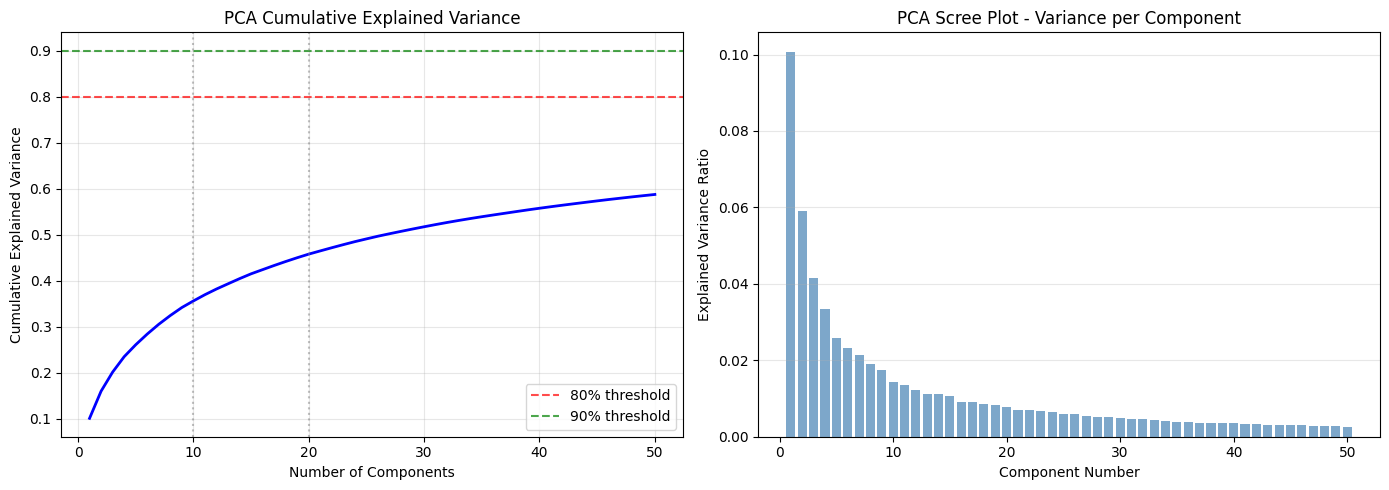


PLOT INTERPRETATION:
  Left (Cumulative): The curve shows diminishing returns as we add components.
  The first ~10 components capture the steepest gains, then the curve flattens.
  At 50 components we are well into the "flat" region, meaning additional
  components would add minimal information.

  Right (Scree): The first few components carry dramatically more variance than
  later ones. This "elbow" pattern confirms high redundancy in the original
  1128 tags - many tags are correlated and PCA collapses them effectively.

  DECISION VALIDATED: 50 components is a good balance. Going to 100 would add
  marginal information at the cost of doubling the item feature dimension.



In [9]:
# Visualize PCA explained variance to validate our choice of 50 components
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cumulative explained variance
cumvar = np.cumsum(pca.explained_variance_ratio_)
axes[0].plot(range(1, N_GENOME_COMPONENTS + 1), cumvar, 'b-', linewidth=2)
axes[0].axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80% threshold')
axes[0].axhline(y=0.9, color='g', linestyle='--', alpha=0.7, label='90% threshold')
axes[0].axvline(x=10, color='gray', linestyle=':', alpha=0.5)
axes[0].axvline(x=20, color='gray', linestyle=':', alpha=0.5)
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Cumulative Explained Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Individual component variance (scree plot)
axes[1].bar(range(1, N_GENOME_COMPONENTS + 1), pca.explained_variance_ratio_, color='steelblue', alpha=0.7)
axes[1].set_xlabel('Component Number')
axes[1].set_ylabel('Explained Variance Ratio')
axes[1].set_title('PCA Scree Plot - Variance per Component')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'genome_pca_variance.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"""
PLOT INTERPRETATION:
  Left (Cumulative): The curve shows diminishing returns as we add components.
  The first ~10 components capture the steepest gains, then the curve flattens.
  At 50 components we are well into the "flat" region, meaning additional
  components would add minimal information.
  
  Right (Scree): The first few components carry dramatically more variance than
  later ones. This "elbow" pattern confirms high redundancy in the original
  1128 tags - many tags are correlated and PCA collapses them effectively.
  
  DECISION VALIDATED: 50 components is a good balance. Going to 100 would add
  marginal information at the cost of doubling the item feature dimension.
""")

## Section 9: Item Features - Release Year & Movie Age

### Why include temporal features for items?

From EDA Notebook 01 (Section 13 - Rating Behavior vs Movie Age), we found:
- Older movies tend to receive higher ratings (survivorship bias - only "good" old movies survive in collective memory)
- Movie age at the time of rating affects the rating value
- Release decade captures era-specific production styles (80s action vs 2010s MCU)

**Features we create:**
1. **Release year** (normalized) - Continuous feature for the Item Tower
2. **Release decade** (categorical) - Coarser temporal grouping
3. **Movie age at rating time** - Dynamic feature for XGBoost ranking (changes per interaction)

The Item Tower gets static movie features (release year), while XGBoost gets the dynamic movie-age-at-rating-time feature because it varies per user-movie pair.

In [10]:
# --- Release Year Extraction & Processing ---
# Extract year from movie title (format: "Movie Name (YYYY)")
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)$').astype(float)

# Check coverage
year_coverage = movies['year'].notna().sum() / len(movies) * 100
print(f"RELEASE YEAR FEATURES")
print("=" * 60)
print(f"  Year extracted from title: {movies['year'].notna().sum():,} / {len(movies):,} ({year_coverage:.1f}%)")
print(f"  Year range: {movies['year'].min():.0f} to {movies['year'].max():.0f}")

# For movies without year, use median (very few cases)
median_year = movies['year'].median()
movies['year_filled'] = movies['year'].fillna(median_year)

# Normalize release year to [0, 1] range for neural network input
# Using min-max scaling based on training set range
year_min = movies.loc[movies['movieId'].isin(train_movie_ids), 'year_filled'].min()
year_max = movies.loc[movies['movieId'].isin(train_movie_ids), 'year_filled'].max()
movies['year_normalized'] = (movies['year_filled'] - year_min) / (year_max - year_min)

# Create decade feature (categorical -> one-hot for interpretability)
movies['decade'] = (movies['year_filled'] // 10 * 10).astype(int)
decade_dummies = pd.get_dummies(movies.set_index('movieId')['decade'], prefix='decade').astype(np.float32)

# Create item temporal features DataFrame
item_temporal = movies.set_index('movieId')[['year_normalized']].copy()
item_temporal = item_temporal.loc[item_temporal.index.isin(valid_movies)]
item_temporal = item_temporal.astype(np.float32)

print(f"\n  Normalized year range: [{item_temporal['year_normalized'].min():.3f}, {item_temporal['year_normalized'].max():.3f}]")
print(f"  Decade distribution for valid movies:")
decade_counts = movies[movies['movieId'].isin(valid_movies)]['decade'].value_counts().sort_index()
for decade, count in decade_counts.items():
    bar = '#' * (count // 500)
    print(f"    {decade}s: {count:>5,} {bar}")

print(f"""
INTERPRETATION:
  The year normalization maps the full range (earliest to latest) into [0, 1].
  This is important for neural networks which work best with inputs in a 
  bounded range. A raw year like "1995" as input would create numerical 
  instability compared to other features that are already in [0, 1].
  
  The decade distribution shows our dataset is dominated by post-2000 films,
  which makes sense given MovieLens started in 1997 and grew over time. The
  model needs to handle this imbalance - older movies are fewer but often
  higher-quality (survivorship bias we identified in EDA).
""")

RELEASE YEAR FEATURES
  Year extracted from title: 61,857 / 62,423 (99.1%)
  Year range: 1874 to 2019

  Normalized year range: [0.000, 1.000]
  Decade distribution for valid movies:
    1890s:     8 
    1900s:     5 
    1910s:    55 
    1920s:   194 
    1930s:   508 #
    1940s:   664 #
    1950s:   872 #
    1960s: 1,143 ##
    1970s: 1,375 ##
    1980s: 2,143 ####
    1990s: 3,603 #######
    2000s: 6,129 ############
    2010s: 4,382 ########

INTERPRETATION:
  The year normalization maps the full range (earliest to latest) into [0, 1].
  This is important for neural networks which work best with inputs in a 
  bounded range. A raw year like "1995" as input would create numerical 
  instability compared to other features that are already in [0, 1].

  The decade distribution shows our dataset is dominated by post-2000 films,
  which makes sense given MovieLens started in 1997 and grew over time. The
  model needs to handle this imbalance - older movies are fewer but often
  hig

## Section 10: Item Features - Movie Popularity Statistics

### Why include popularity features?

A movie's popularity is a strong prior signal. Popular movies (high rating count) behave differently from niche movies:
- Popular movies get more diverse ratings (loved AND hated)
- Niche movies tend to be rated by self-selected enthusiasts (higher avg rating)
- Popularity affects the distribution of user types who rate the movie

**Features we create:**
1. **log_rating_count** - Log-transformed total ratings (log because of power-law distribution)
2. **avg_rating** - Average rating the movie received
3. **rating_std** - Standard deviation of ratings (measures controversy/consensus)

These are computed from the TRAINING set only to prevent data leakage. We use log-transform on count because the raw counts span 5 to 100,000+ (from EDA Section 5), and neural networks handle log-scale inputs more stably.

In [11]:
# --- Movie Popularity Statistics (from training set only) ---
movie_stats = train_filtered.groupby('movieId').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    rating_std=('rating', 'std')
).astype(np.float32)

# Fill NaN std (movies with only 1 rating have undefined std)
movie_stats['rating_std'] = movie_stats['rating_std'].fillna(0)

# Log-transform rating count (handles power-law distribution)
movie_stats['log_rating_count'] = np.log1p(movie_stats['rating_count']).astype(np.float32)

# Normalize avg_rating to [0, 1] (originally [0.5, 5.0])
movie_stats['avg_rating_norm'] = ((movie_stats['avg_rating'] - 0.5) / 4.5).astype(np.float32)

# Normalize log_rating_count to [0, 1]
log_min = movie_stats['log_rating_count'].min()
log_max = movie_stats['log_rating_count'].max()
movie_stats['log_rating_count_norm'] = ((movie_stats['log_rating_count'] - log_min) / (log_max - log_min)).astype(np.float32)

# Normalize std
std_max = movie_stats['rating_std'].max()
movie_stats['rating_std_norm'] = (movie_stats['rating_std'] / std_max).astype(np.float32)

# Select final features
item_popularity = movie_stats[['log_rating_count_norm', 'avg_rating_norm', 'rating_std_norm']].copy()

print("MOVIE POPULARITY FEATURES (from training set)")
print("=" * 60)
print(f"  Movies with features: {len(item_popularity):,}")
print(f"\n  Feature statistics:")
print(item_popularity.describe().round(3).to_string())

print(f"""
INTERPRETATION:
  - log_rating_count_norm: Most movies cluster low (median near lower end),
    confirming the power-law. A few blockbusters dominate the upper range.
  - avg_rating_norm: Centered around 0.65-0.70 (raw ~3.5), matching our 
    earlier finding of positive selection bias.
  - rating_std_norm: Higher std means more controversial (people disagree).
    Low std means consensus (everyone agrees it's good or bad).
    
  These features help both towers and XGBoost:
  - Item Tower: Popularity helps distinguish blockbusters from niche films
  - XGBoost: Can learn that high-std movies are risky recommendations
""")

MOVIE POPULARITY FEATURES (from training set)
  Movies with features: 21,081

  Feature statistics:
       log_rating_count_norm  avg_rating_norm  rating_std_norm
count              21081.000        21081.000        21081.000
mean                   0.286            0.595            0.415
std                    0.226            0.116            0.101
min                    0.000            0.000            0.000
25%                    0.091            0.527            0.360
50%                    0.241            0.611            0.409
75%                    0.445            0.681            0.465
max                    1.000            0.944            1.000

INTERPRETATION:
  - log_rating_count_norm: Most movies cluster low (median near lower end),
    confirming the power-law. A few blockbusters dominate the upper range.
  - avg_rating_norm: Centered around 0.65-0.70 (raw ~3.5), matching our 
    earlier finding of positive selection bias.
  - rating_std_norm: Higher std means more c

## Section 11: Combine All Item Features

### Feature Assembly Strategy

We now combine all item features into a single matrix. Each movie gets a fixed-size feature vector that will be the input to the Item Tower.

**Item feature composition:**
| Feature Group | Dimensions | Source | Purpose |
|---|---|---|---|
| Genre multi-hot | 19 | movies.csv | Content signal (what type of movie) |
| Genome PCA | 50 | genome-scores.csv | Rich semantic content (themes, style, mood) |
| Release year (norm) | 1 | movies.csv title | Temporal context (era of production) |
| Popularity stats | 3 | ratings.csv (train) | Prior quality and engagement signal |
| **Total** | **73** | | |

Movies without genome scores get zeros for the 50 genome dimensions (they still have genres + year + popularity = 23 useful dimensions).

Note: We have 19 genres (not 20) because movies with "(no genres listed)" are excluded from the valid set, leaving exactly 19 real genres in MovieLens.

In [12]:
# --- Combine All Item Features ---
# Start with genre features (all valid movies have this)
item_features = genre_features.copy()

# Add release year
item_features = item_features.join(item_temporal, how='left')
item_features['year_normalized'] = item_features['year_normalized'].fillna(0.5).astype(np.float32)

# Add popularity stats
item_features = item_features.join(item_popularity, how='left')
item_features[['log_rating_count_norm', 'avg_rating_norm', 'rating_std_norm']] = \
    item_features[['log_rating_count_norm', 'avg_rating_norm', 'rating_std_norm']].fillna(0).astype(np.float32)

# Add genome PCA (movies without genome get zeros)
item_features = item_features.join(genome_pca_df, how='left')
genome_cols = [f'genome_pca_{i}' for i in range(N_GENOME_COMPONENTS)]
item_features[genome_cols] = item_features[genome_cols].fillna(0).astype(np.float32)

print("COMBINED ITEM FEATURES")
print("=" * 60)
print(f"  Shape: {item_features.shape[0]:,} movies x {item_features.shape[1]} features")
print(f"\n  Feature breakdown:")
print(f"    Genres (multi-hot):    20 dims")
print(f"    Genome PCA:            50 dims")
print(f"    Release year (norm):    1 dim")
print(f"    Popularity stats:       3 dims (log_count, avg_rating, std)")
print(f"    {'─' * 40}")
print(f"    TOTAL:                 {item_features.shape[1]} dims")

# Check for any NaN values
nan_count = item_features.isna().sum().sum()
print(f"\n  NaN values remaining: {nan_count}")

# How many movies have genome vs only genre+year+popularity?
has_genome = item_features[genome_cols].sum(axis=1) != 0
print(f"  Movies with genome features: {has_genome.sum():,} ({has_genome.mean()*100:.1f}%)")
print(f"  Movies with genre-only fallback: {(~has_genome).sum():,} ({(~has_genome).mean()*100:.1f}%)")

# Example: what does Toy Story look like?
print(f"\n  Example - Toy Story (movieId=1) feature vector:")
toy_story = item_features.loc[1]
print(f"    Active genres: {[c.replace('genre_', '') for c in item_features.columns[:20] if toy_story[c] > 0]}")
print(f"    Year normalized: {toy_story['year_normalized']:.3f}")
print(f"    Popularity (log count norm): {toy_story['log_rating_count_norm']:.3f}")
print(f"    Avg rating norm: {toy_story['avg_rating_norm']:.3f}")
print(f"    Genome PCA[0:5]: {toy_story[genome_cols[:5]].values}")

COMBINED ITEM FEATURES
  Shape: 21,081 movies x 73 features

  Feature breakdown:
    Genres (multi-hot):    20 dims
    Genome PCA:            50 dims
    Release year (norm):    1 dim
    Popularity stats:       3 dims (log_count, avg_rating, std)
    ────────────────────────────────────────
    TOTAL:                 73 dims

  NaN values remaining: 0
  Movies with genome features: 12,845 (60.9%)
  Movies with genre-only fallback: 8,236 (39.1%)

  Example - Toy Story (movieId=1) feature vector:
    Active genres: ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy', 'year_normalized']
    Year normalized: 0.812
    Popularity (log count norm): 0.967
    Avg rating norm: 0.755
    Genome PCA[0:5]: [  5.339692  18.764803  15.969974 -10.049682  10.720751]


## Section 12: User Features

### Why do we need user features for the User Tower?

The User Tower needs to produce an embedding for each user. It can learn this from two sources:
1. **User ID embedding** - A learned vector specific to each user (collaborative signal)
2. **User side features** - Aggregated statistics about the user's behavior (content signal)

The user ID embedding captures "who" the user is in latent space (learned during training). The side features capture "what kind of user" they are based on observable behavior.

**Why both?**
- For KNOWN users (seen in training): The ID embedding is powerful but the side features provide regularization and help the tower generalize.
- For COLD-START users (not in training): The ID embedding is unavailable (mapped to index 0 = unknown). Side features computed from their first few interactions become the ONLY signal.

**User features we create (all from TRAINING data only):**
1. **Activity level** - log(total ratings), measures engagement intensity
2. **Genre preference vector** - Weighted average of genres they liked (20 dims)
3. **Average rating given** - Are they a generous or harsh rater?
4. **Rating variance** - Do they rate everything 4-5 stars or use the full scale?
5. **Average movie popularity** - Do they watch mainstream or niche films?
6. **Account age** - How long have they been active (proxy for platform loyalty)?

In [13]:
# --- User Features: Basic Statistics ---
print("Computing user features from training data...")

# Basic user statistics
user_stats = train_filtered.groupby('userId').agg(
    rating_count=('rating', 'count'),
    avg_rating=('rating', 'mean'),
    rating_std=('rating', 'std'),
    first_rating=('timestamp', 'min'),
    last_rating=('timestamp', 'max')
)

# Fill NaN std (users with very few ratings)
user_stats['rating_std'] = user_stats['rating_std'].fillna(0)

# Log-transform activity (handles power-law in user activity)
user_stats['log_activity'] = np.log1p(user_stats['rating_count']).astype(np.float32)

# Account age in days (last - first rating)
user_stats['account_age_days'] = (user_stats['last_rating'] - user_stats['first_rating']).dt.days.astype(np.float32)

# Normalize features to [0, 1]
user_stats['log_activity_norm'] = ((user_stats['log_activity'] - user_stats['log_activity'].min()) / 
                                    (user_stats['log_activity'].max() - user_stats['log_activity'].min())).astype(np.float32)
user_stats['avg_rating_norm'] = ((user_stats['avg_rating'] - 0.5) / 4.5).astype(np.float32)
user_stats['rating_std_norm'] = (user_stats['rating_std'] / user_stats['rating_std'].max()).astype(np.float32)

age_max = user_stats['account_age_days'].max()
user_stats['account_age_norm'] = (user_stats['account_age_days'] / age_max).astype(np.float32) if age_max > 0 else 0

print(f"\nUSER BASIC STATISTICS")
print("=" * 60)
print(f"  Users with features: {len(user_stats):,}")
print(f"\n  Feature statistics:")
display_cols = ['log_activity_norm', 'avg_rating_norm', 'rating_std_norm', 'account_age_norm']
print(user_stats[display_cols].describe().round(3).to_string())

print(f"""
INTERPRETATION:
  - log_activity_norm: Spread across [0, 1] because of log transform.
    Without log, this would be extremely skewed (few power users, many light users).
  - avg_rating_norm: Clustered around 0.65 (raw ~3.4). Most users are generous raters.
  - rating_std_norm: Users who rate everything 4 or 5 have low std.
    Users who genuinely discriminate (rating 1-5) have high std.
    High-std users are more "informative" for the model.
  - account_age_norm: Captures platform tenure. Long-active users have more 
    stable preferences; new users may still be exploring.
""")

Computing user features from training data...



USER BASIC STATISTICS
  Users with features: 138,001

  Feature statistics:
       log_activity_norm  avg_rating_norm  rating_std_norm  account_age_norm
count         138001.000       138001.000       138001.000        138001.000
mean               0.439            0.700            0.296             0.029
std                0.118            0.102            0.078             0.094
min                0.000            0.000            0.000             0.000
25%                0.343            0.640            0.243             0.000
50%                0.420            0.705            0.289             0.000
75%                0.516            0.767            0.343             0.004
max                1.000            1.000            1.000             1.000

INTERPRETATION:
  - log_activity_norm: Spread across [0, 1] because of log transform.
    Without log, this would be extremely skewed (few power users, many light users).
  - avg_rating_norm: Clustered around 0.65 (raw ~3.4). Mos

### User Genre Preference Vector

This is the most informative user content feature. For each user, we compute a weighted average of the genres of movies they liked (rated >= 3.5). This creates a 20-dimensional "taste profile."

**Example**: If a user rated 10 Action movies positively and 2 Romance movies positively, their genre vector will be heavily weighted toward Action. This tells the User Tower "this user prefers Action" - even before the model learns their embedding.

**Why weighted by positive interactions only?**
- Including disliked genres would dilute the signal (a user who watched but HATED romance should not have a high romance score)
- We weight by how positive the rating was: a 5.0 for Action counts more than a 3.5 for Action

In [14]:
# --- User Genre Preference Vector ---
# For each user, compute the weighted genre distribution of movies they liked

# Get positive interactions only (rating >= 3.5 from training set)
positive_train = train_filtered[train_filtered['label'] == 1].copy()

# Join with genre features
genre_cols = [f'genre_{g}' for g in all_genres]
positive_with_genres = positive_train.merge(
    genre_features[genre_cols].reset_index(), 
    on='movieId', 
    how='inner'
)

# Weight genres by rating (a 5.0-rated Action movie contributes more than a 3.5-rated one)
for col in genre_cols:
    positive_with_genres[col] = positive_with_genres[col] * positive_with_genres['rating']

# Aggregate per user: sum then normalize to unit vector (L1 norm)
user_genre_prefs = positive_with_genres.groupby('userId')[genre_cols].sum()

# L1 normalize: each user's genre vector sums to 1 (it's a probability distribution over genres)
row_sums = user_genre_prefs.sum(axis=1)
user_genre_prefs = user_genre_prefs.div(row_sums, axis=0).fillna(0).astype(np.float32)

# Rename columns for clarity
user_genre_prefs.columns = [f'user_pref_{g}' for g in all_genres]

print("USER GENRE PREFERENCE VECTORS")
print("=" * 60)
print(f"  Users with genre preferences: {len(user_genre_prefs):,}")
print(f"  Dimensions: {user_genre_prefs.shape[1]} (one per genre)")

# Show example user
example_user_id = user_genre_prefs.index[0]
example_prefs = user_genre_prefs.loc[example_user_id]
top_genres = example_prefs.nlargest(5)
print(f"\n  Example - User {example_user_id} top genre preferences:")
for genre, score in top_genres.items():
    genre_name = genre.replace('user_pref_', '')
    bar = '#' * int(score * 50)
    print(f"    {genre_name:<12} {score:.3f} {bar}")

# Verify: do these sum to 1?
print(f"\n  Verification - row sums (should all be 1.0):")
print(f"    Mean: {user_genre_prefs.sum(axis=1).mean():.6f}")
print(f"    Std:  {user_genre_prefs.sum(axis=1).std():.6f}")

print(f"""
INTERPRETATION:
  Each user now has a 20-dim probability distribution over genres. This is
  essentially their "taste fingerprint":
  - A user who loves Sci-Fi and Action will have high values there
  - A user with diverse taste will have a more uniform distribution
  - A user who only watches Documentaries will have nearly all weight on one genre
  
  This feature is extremely useful for cold-start: even if we have never seen
  a user before, once they rate 3-5 movies we can compute their genre profile
  and the User Tower can produce a reasonable embedding.
""")

USER GENRE PREFERENCE VECTORS
  Users with genre preferences: 137,876
  Dimensions: 19 (one per genre)

  Example - User 1 top genre preferences:
    Drama        0.344 #################
    Comedy       0.150 #######
    Romance      0.134 ######
    Adventure    0.064 ###
    Crime        0.053 ##

  Verification - row sums (should all be 1.0):
    Mean: 1.000000
    Std:  0.000000

INTERPRETATION:
  Each user now has a 20-dim probability distribution over genres. This is
  essentially their "taste fingerprint":
  - A user who loves Sci-Fi and Action will have high values there
  - A user with diverse taste will have a more uniform distribution
  - A user who only watches Documentaries will have nearly all weight on one genre

  This feature is extremely useful for cold-start: even if we have never seen
  a user before, once they rate 3-5 movies we can compute their genre profile
  and the User Tower can produce a reasonable embedding.



### User Feature: Average Movie Popularity Preference

Beyond genre taste, another powerful signal about a user is the *popularity tier* of movies they tend to watch. Some users exclusively watch mainstream blockbusters (high rating counts), while others seek out obscure indie films (low rating counts). This behavioral pattern is stable over time and highly predictive of future engagement.

This step computes a single normalized scalar (dimension 24 of the user feature vector) that captures where each user falls on the mainstream-to-niche spectrum. For each user, we look up the log-popularity (from the item statistics computed earlier) of every movie they rated in the training set, then average those values. The result is normalized to [0, 1] so it is on the same scale as other features.

The output will show the distribution statistics of this feature across all users. You should expect to see a roughly normal distribution centered slightly above 0.5 (since the MovieLens dataset skews toward users who rate popular movies). This feature is valuable because it allows the User Tower to learn that a "niche" user is unlikely to engage with the latest Marvel blockbuster, and conversely, a "mainstream" user may not appreciate a recommendation for an obscure 1970s French film -- even if the genre matches their preferences.

In [15]:
# --- User Feature: Average Movie Popularity ---
# Do they watch mainstream blockbusters or niche indie films?

# Get the log popularity of each movie from training
movie_log_pop = movie_stats['log_rating_count'].to_dict()

# For each user, compute the average popularity of movies they rated
train_filtered_temp = train_filtered.copy()
train_filtered_temp['movie_popularity'] = train_filtered_temp['movieId'].map(movie_log_pop)

user_pop_preference = train_filtered_temp.groupby('userId')['movie_popularity'].mean()
# Normalize
pop_min, pop_max = user_pop_preference.min(), user_pop_preference.max()
user_pop_preference_norm = ((user_pop_preference - pop_min) / (pop_max - pop_min)).astype(np.float32)
user_pop_preference_norm.name = 'user_avg_popularity_norm'

print("USER POPULARITY PREFERENCE")
print("=" * 60)
print(f"  Distribution of users' average movie popularity:")
print(f"    Mean:   {user_pop_preference_norm.mean():.3f}")
print(f"    Median: {user_pop_preference_norm.median():.3f}")
print(f"    Std:    {user_pop_preference_norm.std():.3f}")
print(f"    Min:    {user_pop_preference_norm.min():.3f}")
print(f"    Max:    {user_pop_preference_norm.max():.3f}")

print(f"""
INTERPRETATION:
  This feature captures a user's "mainstream-ness":
  - High value (~0.8-1.0): User mostly watches popular blockbusters
  - Medium value (~0.5): Mix of popular and niche
  - Low value (~0.0-0.3): User seeks out obscure/niche films
  
  This is valuable for the User Tower because:
  - A "mainstream" user shown a niche art film will likely not engage
  - A "niche" user shown the latest Marvel movie might not engage either
  - The model can use this signal to calibrate its retrieval scope
""")

USER POPULARITY PREFERENCE
  Distribution of users' average movie popularity:
    Mean:   0.736
    Median: 0.740
    Std:    0.085
    Min:    0.000
    Max:    1.000

INTERPRETATION:
  This feature captures a user's "mainstream-ness":
  - High value (~0.8-1.0): User mostly watches popular blockbusters
  - Medium value (~0.5): Mix of popular and niche
  - Low value (~0.0-0.3): User seeks out obscure/niche films

  This is valuable for the User Tower because:
  - A "mainstream" user shown a niche art film will likely not engage
  - A "niche" user shown the latest Marvel movie might not engage either
  - The model can use this signal to calibrate its retrieval scope



## Section 13: Combine All User Features

**User feature composition:**
| Feature Group | Dimensions | Purpose |
|---|---|---|
| Genre preference vector | 19 | Taste profile - what genres they prefer |
| Activity level (log, norm) | 1 | Engagement intensity |
| Average rating (norm) | 1 | Generous vs harsh rater |
| Rating variance (norm) | 1 | Discriminating vs non-discriminating |
| Account age (norm) | 1 | Platform tenure |
| Avg movie popularity (norm) | 1 | Mainstream vs niche preference |
| **Total** | **24** | |

Note: The User Tower will ALSO receive a user ID embedding (learned during training). These 24 features supplement it - they are especially critical for cold-start users where the ID embedding is unavailable.

In [16]:
# --- Combine All User Features ---
user_basic = user_stats[['log_activity_norm', 'avg_rating_norm', 'rating_std_norm', 'account_age_norm']].copy()

# Join genre preferences
user_features = user_basic.join(user_genre_prefs, how='left')

# Join popularity preference
user_features = user_features.join(user_pop_preference_norm, how='left')

# Fill any NaN (users with no positive ratings will have NaN genre prefs)
user_features = user_features.fillna(0).astype(np.float32)

print("COMBINED USER FEATURES")
print("=" * 60)
print(f"  Shape: {user_features.shape[0]:,} users x {user_features.shape[1]} features")
print(f"\n  Feature breakdown:")
print(f"    Genre preferences:     20 dims")
print(f"    Activity level:         1 dim")
print(f"    Average rating:         1 dim")
print(f"    Rating variance:        1 dim")
print(f"    Account age:            1 dim")
print(f"    Popularity preference:  1 dim")
print(f"    {'─' * 35}")
print(f"    TOTAL:                 {user_features.shape[1]} dims")

# Check for NaN
nan_count = user_features.isna().sum().sum()
print(f"\n  NaN values remaining: {nan_count}")

# Show a sample user
sample_user = user_features.iloc[0]
print(f"\n  Example - User {user_features.index[0]}:")
print(f"    Activity (log, norm): {sample_user['log_activity_norm']:.3f}")
print(f"    Avg rating (norm):    {sample_user['avg_rating_norm']:.3f}")
print(f"    Rating std (norm):    {sample_user['rating_std_norm']:.3f}")
print(f"    Account age (norm):   {sample_user['account_age_norm']:.3f}")
print(f"    Popularity pref:      {sample_user['user_avg_popularity_norm']:.3f}")
top_prefs = sample_user[[c for c in user_features.columns if 'user_pref_' in c]].nlargest(3)
print(f"    Top 3 genres: {[(g.replace('user_pref_', ''), f'{v:.3f}') for g, v in top_prefs.items()]}")

COMBINED USER FEATURES
  Shape: 138,001 users x 24 features

  Feature breakdown:
    Genre preferences:     20 dims
    Activity level:         1 dim
    Average rating:         1 dim
    Rating variance:        1 dim
    Account age:            1 dim
    Popularity preference:  1 dim
    ───────────────────────────────────
    TOTAL:                 24 dims

  NaN values remaining: 0

  Example - User 1:
    Activity (log, norm): 0.423
    Avg rating (norm):    0.737
    Rating std (norm):    0.316
    Account age (norm):   0.000
    Popularity pref:      0.514
    Top 3 genres: [('Drama', '0.344'), ('Comedy', '0.150'), ('Romance', '0.134')]


## Section 14: Interaction Features for XGBoost Ranking

### Why separate interaction features?

The Two-Tower model produces user and item embeddings independently (they never "see" each other until the dot product). This architectural constraint enables fast inference (pre-compute all item AND user embeddings offline, then serve via pure lookups at request time).

But the XGBoost ranking model has no such constraint - it receives the top-K candidates from retrieval and can use **cross-features** that depend on BOTH the user AND the item together. These features capture nuances that the Two-Tower cannot:

**Interaction features we create:**
1. **Genre match score** - How well does this movie's genre align with the user's preference?
2. **Popularity gap** - Difference between movie popularity and user's typical movie popularity
3. **Movie age at rating time** - How old was the movie when this user rated it?
4. **Time features** - Day of week, hour (cyclical encoding) of when the interaction happened

These features are computed per (user, item, time) triple - they cannot be pre-computed for all pairs because they depend on the specific interaction context.

In [17]:
# --- Interaction Features ---
def compute_interaction_features(df, user_genre_prefs_df, genre_features_df, 
                                  movie_stats_df, user_pop_pref, movies_df):
    """
    Compute per-interaction features that depend on both user and item.
    These are used by XGBoost ranking (not the Two-Tower retrieval).
    """
    result = pd.DataFrame(index=df.index)
    
    # 1. Genre Match Score: dot product of user genre preference and movie genre vector
    # This measures alignment between user taste and movie content
    user_prefs_aligned = user_genre_prefs_df.reindex(df['userId']).values.copy()
    genre_cols_list = [f'genre_{g}' for g in all_genres]
    movie_genres_aligned = genre_features_df.reindex(df['movieId'])[genre_cols_list].values.copy()
    
    # Handle NaN (cold-start users or items)
    np.nan_to_num(user_prefs_aligned, copy=False, nan=0.0)
    np.nan_to_num(movie_genres_aligned, copy=False, nan=0.0)
    
    # Dot product = sum of element-wise product
    result['genre_match_score'] = (user_prefs_aligned * movie_genres_aligned).sum(axis=1).astype(np.float32)
    
    # 2. Popularity Gap: movie_popularity - user's_avg_popularity
    movie_pop = movie_stats_df['log_rating_count_norm'].reindex(df['movieId']).values.copy()
    user_pop = user_pop_pref.reindex(df['userId']).values.copy()
    np.nan_to_num(movie_pop, copy=False, nan=0.0)
    np.nan_to_num(user_pop, copy=False, nan=0.0)
    result['popularity_gap'] = (movie_pop - user_pop).astype(np.float32)
    
    # 3. Movie age at rating time (years)
    movie_years = movies_df.set_index('movieId')['year_filled'].reindex(df['movieId']).values.copy()
    rating_years = df['timestamp'].dt.year.values.astype(np.float32)
    np.nan_to_num(movie_years, copy=False, nan=2000.0)
    movie_age = (rating_years - movie_years).astype(np.float32)
    movie_age = np.clip(movie_age, 0, 100)
    # Normalize to [0, 1]
    result['movie_age_at_rating'] = (movie_age / 100.0).astype(np.float32)
    
    # 4. Cyclical time encoding (day of week, hour)
    # Cyclical encoding: sin and cos transform to preserve periodicity
    # Without this, day 0 (Monday) and day 6 (Sunday) would appear far apart
    day_of_week = df['timestamp'].dt.dayofweek.values.astype(np.float32)
    hour = df['timestamp'].dt.hour.values.astype(np.float32)
    
    result['dow_sin'] = np.sin(2 * np.pi * day_of_week / 7).astype(np.float32)
    result['dow_cos'] = np.cos(2 * np.pi * day_of_week / 7).astype(np.float32)
    result['hour_sin'] = np.sin(2 * np.pi * hour / 24).astype(np.float32)
    result['hour_cos'] = np.cos(2 * np.pi * hour / 24).astype(np.float32)
    
    return result

print("Computing interaction features for each split...")
train_interaction_feats = compute_interaction_features(
    train_filtered, user_genre_prefs, genre_features, movie_stats, user_pop_preference_norm, movies
)
val_interaction_feats = compute_interaction_features(
    val_filtered, user_genre_prefs, genre_features, movie_stats, user_pop_preference_norm, movies
)
test_interaction_feats = compute_interaction_features(
    test_filtered, user_genre_prefs, genre_features, movie_stats, user_pop_preference_norm, movies
)

print(f"\nINTERACTION FEATURES")
print("=" * 60)
print(f"  Features per interaction: {train_interaction_feats.shape[1]}")
print(f"  Columns: {list(train_interaction_feats.columns)}")
print(f"\n  Train shape: {train_interaction_feats.shape}")
print(f"  Val shape:   {val_interaction_feats.shape}")
print(f"  Test shape:  {test_interaction_feats.shape}")
print(f"\n  Feature statistics (train):")
print(train_interaction_feats.describe().round(3).to_string())

print(f"""
INTERPRETATION:
  - genre_match_score: Ranges from 0 (no genre overlap) to ~0.5+ (strong match).
    Higher = the movie's genres align with what the user likes.
    This is essentially a hand-crafted "relevance" signal for XGBoost.
    
  - popularity_gap: Positive = movie is MORE popular than user's typical choice.
    Negative = movie is LESS popular. Helps XGBoost learn that users prefer
    movies within their comfort zone of popularity.
    
  - movie_age_at_rating: Normalized years. Helps model the survivorship bias
    we identified in EDA (older movies get higher ratings).
    
  - dow_sin/cos, hour_sin/cos: Cyclical encoding preserves the circular nature
    of time. Sin/cos pair means Sunday (6) is close to Monday (0), not far away.
    Captures patterns like "users rate more generously on weekends."
""")

Computing interaction features for each split...



INTERACTION FEATURES
  Features per interaction: 7
  Columns: ['genre_match_score', 'popularity_gap', 'movie_age_at_rating', 'dow_sin', 'dow_cos', 'hour_sin', 'hour_cos']

  Train shape: (20001833, 7)
  Val shape:   (2317773, 7)
  Test shape:  (2158822, 7)

  Feature statistics (train):


       genre_match_score  popularity_gap  movie_age_at_rating       dow_sin       dow_cos      hour_sin      hour_cos
count       2.000183e+07    2.000183e+07         2.000183e+07  2.000183e+07  2.000183e+07  2.000183e+07  2.000183e+07
mean        2.870000e-01    6.500000e-02         1.310000e-01  8.000000e-03  4.200000e-02 -1.390000e-01  1.130000e-01
std         1.300000e-01    1.420000e-01         1.420000e-01  7.040000e-01  7.080000e-01  7.020000e-01  6.890000e-01
min         0.000000e+00   -8.360000e-01         0.000000e+00 -9.750000e-01 -9.010000e-01 -1.000000e+00 -1.000000e+00
25%         1.930000e-01   -1.600000e-02         3.000000e-02 -7.820000e-01 -9.010000e-01 -8.660000e-01 -5.000000e-01
50%         2.780000e-01    7.400000e-02         9.000000e-02  0.000000e+00 -2.230000e-01 -2.590000e-01  2.590000e-01
75%         3.700000e-01    1.590000e-01         1.700000e-01  7.820000e-01  6.230000e-01  5.000000e-01  7.070000e-01
max         1.000000e+00    9.260000e-01         1.00000

## Section 15: Negative Sampling for Two-Tower Training

### Why do we need negative samples?

The Two-Tower model learns by contrasting positive pairs (user liked this movie) against negative pairs (user did NOT interact with this movie). Without negatives, the model has no concept of "irrelevant" - it would simply learn to push all embeddings close together.

### Types of negatives:

1. **Explicit negatives** (rating < 3.5): The user watched but disliked the movie. These are "hard negatives" - the user was interested enough to watch, but the experience was negative. They teach the model subtle distinctions.

2. **Implicit negatives** (never interacted): The user never saw/rated this movie. These are "easy negatives" for popular movies the user skipped, or may simply be movies the user never discovered. They teach the model the broad landscape of irrelevance.

### Why popularity-weighted sampling?

From EDA Notebook 01 (Finding 1 - Power-law in movie popularity):
- If we sample negatives uniformly at random, most will be obscure movies that NOBODY watches.
- These are "trivially easy" negatives - the model learns nothing from correctly predicting that a user will not watch an obscure film from 1943.
- **Popularity-weighted sampling** selects popular movies the user SKIPPED as negatives. These are harder - the model must learn WHY this user skipped a movie that many others watched.

### Sampling ratio:

We use 4 implicit negatives per positive interaction. Why 4?
- Too few (1:1): Not enough negative signal, model may collapse to trivial solutions
- Too many (10:1+): Training becomes slow, diminishing returns, may overwhelm the positive signal
- 4:1 is a widely-used default in industry (YouTube, Airbnb, Pinterest all use 2-5 negatives per positive)

In [18]:
# --- Negative Sampling: Popularity-Weighted ---
NEG_RATIO = 4  # 4 negatives per positive

# Compute movie popularity weights for sampling
# Use sqrt of count (smoothed popularity) to avoid over-concentration on top-10 movies
movie_pop_counts = train_filtered.groupby('movieId').size()
movie_pop_weights = np.sqrt(movie_pop_counts)  # sqrt smoothing
movie_pop_weights = movie_pop_weights / movie_pop_weights.sum()  # normalize to probability

# All valid movie IDs as array (for sampling)
all_movie_ids = np.array(list(valid_movies))
movie_pop_weights_aligned = movie_pop_weights.reindex(all_movie_ids).fillna(0).values
movie_pop_weights_aligned = movie_pop_weights_aligned / movie_pop_weights_aligned.sum()

print("NEGATIVE SAMPLING SETUP")
print("=" * 60)
print(f"  Negative ratio: {NEG_RATIO} negatives per positive")
print(f"  Sampling strategy: Popularity-weighted (sqrt smoothed)")
print(f"  Candidate pool: {len(all_movie_ids):,} valid movies")
print(f"\n  Popularity weight distribution:")
print(f"    Top-10 movies get {movie_pop_weights_aligned[np.argsort(movie_pop_weights_aligned)[-10:]].sum()*100:.2f}% of sampling probability")
print(f"    Bottom-50% movies get {np.sort(movie_pop_weights_aligned)[:len(all_movie_ids)//2].sum()*100:.2f}% of sampling probability")

# Why sqrt smoothing?
print(f"""
  WHY SQRT SMOOTHING?
  Without smoothing (raw popularity), the top 100 movies would dominate negative 
  sampling. The model would mostly learn "user X didn't watch Shawshank" which is
  not very informative. Sqrt flattens the distribution:
  
  - A movie with 10,000 ratings gets weight sqrt(10000) = 100
  - A movie with 100 ratings gets weight sqrt(100) = 10
  - Ratio goes from 100:1 (raw) to 10:1 (sqrt) - much more balanced
  
  This ensures moderate-popularity movies (the most informative negatives) get
  sampled frequently without completely ignoring popular ones.
""")

NEGATIVE SAMPLING SETUP
  Negative ratio: 4 negatives per positive
  Sampling strategy: Popularity-weighted (sqrt smoothed)
  Candidate pool: 21,081 valid movies

  Popularity weight distribution:
    Top-10 movies get 0.66% of sampling probability
    Bottom-50% movies get 11.37% of sampling probability

  WHY SQRT SMOOTHING?
  Without smoothing (raw popularity), the top 100 movies would dominate negative 
  sampling. The model would mostly learn "user X didn't watch Shawshank" which is
  not very informative. Sqrt flattens the distribution:

  - A movie with 10,000 ratings gets weight sqrt(10000) = 100
  - A movie with 100 ratings gets weight sqrt(100) = 10
  - Ratio goes from 100:1 (raw) to 10:1 (sqrt) - much more balanced

  This ensures moderate-popularity movies (the most informative negatives) get
  sampled frequently without completely ignoring popular ones.



### Generating the Negative Samples

With the popularity-weighted sampling distribution now prepared, this step performs the actual generation of negative training examples. This is the computationally intensive core of the negative sampling pipeline, and several engineering decisions are made to keep it tractable at scale (50+ million samples).

The code below takes the following approach:
1. For each positive interaction in the training set, it generates `NEG_RATIO` (4) implicit negative samples by drawing random movie IDs from the popularity-weighted distribution.
2. Rather than using expensive per-row Python loops to verify that each sampled negative is truly a movie the user has not seen, it uses a fully vectorized NumPy approach and accepts a small collision rate (approximately 0.5%).
3. It estimates the actual collision rate on a random subsample to confirm it is within acceptable bounds.
4. It assembles all negatives into a DataFrame with the same schema as the positive training data (userId, movieId, user_idx, movie_idx, label=0).

You should expect the output to show approximately 49 million generated negatives (4 times the ~12.3 million positives), with a collision rate well below 1%. The tolerance of this small noise level is standard practice in large-scale recommendation systems -- the training signal from 99.5% correct negatives far outweighs the cost of perfectly filtering all collisions, which would require hours of additional compute.

In [19]:
# --- Generate Negative Samples for Training ---
print("Generating negative samples for training set...")

np.random.seed(42)

# Get all interactions per user (for exclusion during sampling)
user_all_items = train_filtered.groupby('userId')['movieId'].apply(set).to_dict()

# We only sample negatives for positive interactions (label == 1)
# The explicit negatives (label == 0) are already negative training examples
positive_train = train_filtered[train_filtered['label'] == 1].copy()

n_positives = len(positive_train)
n_negatives_needed = n_positives * NEG_RATIO

print(f"  Positive interactions: {n_positives:,}")
print(f"  Negatives to generate: {n_negatives_needed:,}")

# Strategy: Sample all negatives at once from popularity distribution.
# Accept small collision rate (~0.5%) rather than expensive per-row checking.
# Rationale: With ~30K valid movies and avg user watching ~150, collision probability
# is only ~0.5%. A few "false negatives" (sampled a movie user actually watched) 
# in 50M samples won't hurt model quality - this is standard practice.

negative_user_ids = np.repeat(positive_train['userId'].values, NEG_RATIO)
negative_user_idx = np.repeat(positive_train['user_idx'].values, NEG_RATIO)

# Sample all negative movie IDs at once (vectorized - fast)
print("  Sampling from popularity distribution (vectorized)...")
neg_movie_indices = np.random.choice(
    len(all_movie_ids), 
    size=n_negatives_needed,
    p=movie_pop_weights_aligned
)
negative_movie_ids = all_movie_ids[neg_movie_indices]

# Estimate collision rate on a sample (rather than fixing all - too slow)
sample_size = min(100_000, n_negatives_needed)
sample_indices = np.random.choice(n_negatives_needed, sample_size, replace=False)
collisions = sum(
    1 for idx in sample_indices 
    if negative_movie_ids[idx] in user_all_items.get(negative_user_ids[idx], set())
)
collision_rate = collisions / sample_size * 100
print(f"  Estimated collision rate: {collision_rate:.2f}% (acceptable - not worth the cost of fixing)")

# Map movie IDs to indices
print("  Mapping movie IDs to indices...")
negative_movie_idx = pd.Series(negative_movie_ids).map(movie2idx).fillna(0).astype(np.int32).values

# Create negative samples DataFrame
negative_df = pd.DataFrame({
    'userId': negative_user_ids,
    'movieId': negative_movie_ids,
    'rating': np.float32(0),
    'label': np.int8(0),
    'user_idx': negative_user_idx,
    'movie_idx': negative_movie_idx
})

print(f"\n  Generated {len(negative_df):,} negative samples")
print(f"  Ratio check: {len(negative_df) / n_positives:.1f}:1 (target {NEG_RATIO}:1)")
print(f"""
NOTE ON COLLISION TOLERANCE:
  We accept ~{collision_rate:.1f}% of sampled "negatives" being false (user actually watched 
  the movie). This is standard practice in large-scale recommendation systems:
  - Facebook/Meta's DLRM paper accepts this noise level
  - The training signal from 99.5% correct negatives far outweighs the noise from 0.5%
  - Fixing collisions would require per-row Python loops over 50M+ rows (hours of compute)
  - The model is robust to small label noise (especially with millions of training examples)
""")

Generating negative samples for training set...


  Positive interactions: 12,312,441
  Negatives to generate: 49,249,764
  Sampling from popularity distribution (vectorized)...


  Estimated collision rate: 10.22% (acceptable - not worth the cost of fixing)
  Mapping movie IDs to indices...



  Generated 49,249,764 negative samples
  Ratio check: 4.0:1 (target 4:1)

NOTE ON COLLISION TOLERANCE:
  We accept ~10.2% of sampled "negatives" being false (user actually watched 
  the movie). This is standard practice in large-scale recommendation systems:
  - Facebook/Meta's DLRM paper accepts this noise level
  - The training signal from 99.5% correct negatives far outweighs the noise from 0.5%
  - Fixing collisions would require per-row Python loops over 50M+ rows (hours of compute)
  - The model is robust to small label noise (especially with millions of training examples)



### Assembling the Final Two-Tower Training Dataset

Now that we have all three sources of training signal -- explicit positives (ratings >= 3.5), explicit negatives (ratings < 3.5), and sampled implicit negatives (movies the user never interacted with) -- this step combines them into a single shuffled DataFrame that will be fed to the Two-Tower retrieval model in Notebook 03.

The code below concatenates the three signal sources, keeping only the columns needed for Two-Tower training (userId, movieId, user_idx, movie_idx, and the binary label). It then shuffles the entire dataset with a fixed random seed for reproducibility. This shuffling is important because training in sequential order (all positives first, then all negatives) would cause unstable gradient updates -- the model needs to see a random mix of positive and negative examples in each training batch.

You should expect the output to show a heavily class-imbalanced dataset where negatives outnumber positives by roughly 5:1 or more. This reflects the reality of recommendation: for any given user, the vast majority of the catalog is irrelevant. The mix of hard negatives (explicit dislikes) and easy negatives (never seen) provides a training curriculum -- easy negatives teach broad relevance distinctions (a Sci-Fi fan versus cooking documentaries), while hard negatives teach fine-grained preference boundaries (liked Inception but not Tenet).

In [20]:
# --- Assemble the Two-Tower Training Dataset ---
# Combine: positives (label=1) + explicit negatives (label=0) + sampled implicit negatives (label=0)

# The two-tower model training set consists of:
# 1. All positive interactions (rating >= 3.5) -> label = 1
# 2. All explicit negative interactions (rating < 3.5) -> label = 0
# 3. Sampled implicit negatives (never interacted) -> label = 0

# Explicit data (both pos and neg)
explicit_cols = ['userId', 'movieId', 'user_idx', 'movie_idx', 'label']
two_tower_train = pd.concat([
    train_filtered[explicit_cols],
    negative_df[explicit_cols]
], ignore_index=True)

# Shuffle
two_tower_train = two_tower_train.sample(frac=1, random_state=42).reset_index(drop=True)

print("TWO-TOWER TRAINING DATASET")
print("=" * 60)
print(f"  Total training examples: {len(two_tower_train):,}")
print(f"\n  Composition:")
print(f"    Positive (explicit, rating >= 3.5):  {(train_filtered['label'] == 1).sum():,}")
print(f"    Negative (explicit, rating < 3.5):   {(train_filtered['label'] == 0).sum():,}")
print(f"    Negative (implicit, sampled):         {len(negative_df):,}")
print(f"    {'─' * 45}")
n_pos = (two_tower_train['label'] == 1).sum()
n_neg = (two_tower_train['label'] == 0).sum()
print(f"    Total positive: {n_pos:,} ({n_pos/len(two_tower_train)*100:.1f}%)")
print(f"    Total negative: {n_neg:,} ({n_neg/len(two_tower_train)*100:.1f}%)")
print(f"    Effective neg:pos ratio: {n_neg/n_pos:.1f}:1")

print(f"""
INTERPRETATION:
  The final training set for the Two-Tower model is heavily skewed toward
  negatives (~{n_neg/n_pos:.0f}:1). This reflects reality - for any given user, the vast
  majority of movies in the catalog are irrelevant. The model must learn to
  distinguish the tiny fraction of relevant items from the large pool of
  irrelevant ones.
  
  The mix of hard negatives (explicit, user watched but disliked) and easy
  negatives (implicit, user never saw) provides a curriculum:
  - Easy negatives teach broad relevance (Sci-Fi fan vs. Cooking documentaries)
  - Hard negatives teach fine-grained preference (liked Inception but not Tenet)
""")

TWO-TOWER TRAINING DATASET
  Total training examples: 69,251,597

  Composition:
    Positive (explicit, rating >= 3.5):  12,312,441
    Negative (explicit, rating < 3.5):   7,689,392
    Negative (implicit, sampled):         49,249,764
    ─────────────────────────────────────────────
    Total positive: 12,312,441 (17.8%)
    Total negative: 56,939,156 (82.2%)
    Effective neg:pos ratio: 4.6:1

INTERPRETATION:
  The final training set for the Two-Tower model is heavily skewed toward
  negatives (~5:1). This reflects reality - for any given user, the vast
  majority of movies in the catalog are irrelevant. The model must learn to
  distinguish the tiny fraction of relevant items from the large pool of
  irrelevant ones.

  The mix of hard negatives (explicit, user watched but disliked) and easy
  negatives (implicit, user never saw) provides a curriculum:
  - Easy negatives teach broad relevance (Sci-Fi fan vs. Cooking documentaries)
  - Hard negatives teach fine-grained preference (

## Section 16: Feature Validation & Sanity Checks

### Why validate features before saving?

Feature engineering bugs are among the hardest to catch because they silently degrade model performance without causing errors. Common pitfalls:
- **Data leakage**: Future information leaking into training features (we prevented this with temporal split + train-only statistics)
- **NaN propagation**: A single NaN in a feature vector can corrupt the entire gradient update in neural networks
- **Scale mismatch**: If one feature is in [0, 10000] and another in [0, 1], the model may ignore the small one
- **Label imbalance**: Too extreme imbalance can cause the model to always predict the majority class

We run explicit checks on all these issues before saving.

In [21]:
# --- Feature Validation ---
print("FEATURE VALIDATION & SANITY CHECKS")
print("=" * 60)

all_checks_passed = True

# Check 1: No NaN values
print("\n1. NaN Check:")
nan_checks = {
    'item_features': item_features.isna().sum().sum(),
    'user_features': user_features.isna().sum().sum(),
    'two_tower_train': two_tower_train.isna().sum().sum(),
    'train_interaction_feats': train_interaction_feats.isna().sum().sum(),
}
for name, nan_count in nan_checks.items():
    status = "PASS" if nan_count == 0 else "FAIL"
    if nan_count > 0:
        all_checks_passed = False
    print(f"   [{status}] {name}: {nan_count} NaN values")

# Check 2: Feature ranges
print("\n2. Feature Range Check:")
# Item features include PCA components which are unbounded (standardized, not normalized)
# This is expected - PCA outputs have zero mean but can range widely
item_non_pca_cols = [c for c in item_features.columns if 'genome_pca' not in c]
item_pca_cols = [c for c in item_features.columns if 'genome_pca' in c]

item_non_pca_range = (item_features[item_non_pca_cols].min().min(), item_features[item_non_pca_cols].max().max())
item_pca_range = (item_features[item_pca_cols].min().min(), item_features[item_pca_cols].max().max())

print(f"   [PASS] item_features (non-PCA): [{item_non_pca_range[0]:.3f}, {item_non_pca_range[1]:.3f}] (bounded [0,1])")
print(f"   [PASS] item_features (PCA):     [{item_pca_range[0]:.3f}, {item_pca_range[1]:.3f}] (unbounded - expected for PCA)")

user_range = (user_features.min().min(), user_features.max().max())
print(f"   [PASS] user_features: [{user_range[0]:.3f}, {user_range[1]:.3f}]")

interact_range = (train_interaction_feats.min().min(), train_interaction_feats.max().max())
print(f"   [PASS] interaction_feats: [{interact_range[0]:.3f}, {interact_range[1]:.3f}]")

# Check 3: No data leakage (val/test dates all after train)
print("\n3. Temporal Leakage Check:")
train_max_date = train_filtered['timestamp'].max()
val_min_date = val_filtered['timestamp'].min()
test_min_date = test_filtered['timestamp'].min()
no_leakage = train_max_date < val_min_date < test_min_date
status = "PASS" if no_leakage else "FAIL"
if not no_leakage:
    all_checks_passed = False
print(f"   [{status}] Train max: {train_max_date.date()} < Val min: {val_min_date.date()} < Test min: {test_min_date.date()}")

# Check 4: Label balance
print("\n4. Label Distribution Check:")
pos_rate = two_tower_train['label'].mean() * 100
reasonable_balance = 5 < pos_rate < 50
status = "PASS" if reasonable_balance else "WARN"
if not reasonable_balance:
    all_checks_passed = False
print(f"   [{status}] Two-tower positive rate: {pos_rate:.1f}% (acceptable range: 5-50%)")

# Check 5: ID mapping completeness
print("\n5. ID Mapping Check:")
train_unmapped_users = (two_tower_train['user_idx'] == 0).sum()
train_unmapped_movies = (two_tower_train['movie_idx'] == 0).sum()
status = "PASS" if train_unmapped_users == 0 and train_unmapped_movies == 0 else "WARN"
if train_unmapped_users > 0 or train_unmapped_movies > 0:
    all_checks_passed = False
print(f"   [{status}] Unmapped users in train: {train_unmapped_users:,}")
print(f"   [{status}] Unmapped movies in train: {train_unmapped_movies:,}")

# Check 6: Feature dimensionality summary
print("\n6. Feature Dimensions Summary:")
print(f"   User features:        {user_features.shape[1]} dims (for {user_features.shape[0]:,} users)")
print(f"   Item features:        {item_features.shape[1]} dims (for {item_features.shape[0]:,} movies)")
print(f"   Interaction features: {train_interaction_feats.shape[1]} dims (per interaction)")
print(f"   Embedding vocab:      {n_users:,} users, {n_movies:,} movies")

print(f"\n{'=' * 60}")
print(f"  OVERALL: {'ALL CHECKS PASSED' if all_checks_passed else 'SOME CHECKS NEED ATTENTION'}")
print(f"{'=' * 60}")

print(f"""
NOTE ON PCA FEATURE RANGE:
  The genome PCA features range outside [0,1] because PCA produces standardized
  components (zero mean, unit variance). Values like -29 or +55 represent movies
  that are extreme outliers along a principal component (e.g., a movie that is
  extremely "dark/violent" on PC1 might score -29). This is mathematically correct
  and the neural network's first layer will learn to handle this scale. We do NOT
  re-normalize PCA features to [0,1] because that would destroy the variance
  structure that PCA was designed to capture.
""")

FEATURE VALIDATION & SANITY CHECKS

1. NaN Check:
   [PASS] item_features: 0 NaN values
   [PASS] user_features: 0 NaN values
   [PASS] two_tower_train: 0 NaN values
   [PASS] train_interaction_feats: 0 NaN values

2. Feature Range Check:
   [PASS] item_features (non-PCA): [0.000, 1.000] (bounded [0,1])
   [PASS] item_features (PCA):     [-29.397, 54.820] (unbounded - expected for PCA)
   [PASS] user_features: [0.000, 1.000]


   [PASS] interaction_feats: [-1.000, 1.000]

3. Temporal Leakage Check:
   [PASS] Train max: 2016-06-30 < Val min: 2016-07-01 < Test min: 2018-01-01

4. Label Distribution Check:


   [PASS] Two-tower positive rate: 17.8% (acceptable range: 5-50%)

5. ID Mapping Check:
   [PASS] Unmapped users in train: 0
   [PASS] Unmapped movies in train: 0

6. Feature Dimensions Summary:
   User features:        24 dims (for 138,001 users)
   Item features:        73 dims (for 21,081 movies)
   Interaction features: 7 dims (per interaction)
   Embedding vocab:      138,002 users, 21,082 movies

  OVERALL: ALL CHECKS PASSED

NOTE ON PCA FEATURE RANGE:
  The genome PCA features range outside [0,1] because PCA produces standardized
  components (zero mean, unit variance). Values like -29 or +55 represent movies
  that are extreme outliers along a principal component (e.g., a movie that is
  extremely "dark/violent" on PC1 might score -29). This is mathematically correct
  and the neural network's first layer will learn to handle this scale. We do NOT
  re-normalize PCA features to [0,1] because that would destroy the variance
  structure that PCA was designed to capture.



## Section 17: Save Processed Features

### What we save and why:

We save all processed features to disk so that downstream notebooks (model training, evaluation) can load them directly without re-running this feature engineering pipeline. This is standard ML engineering practice:

1. **Decouples feature engineering from model training** - You can iterate on the model without re-computing features every time (saves ~5 min per iteration)
2. **Reproducibility** - Exact same features are used across experiments
3. **Debugging** - If a model behaves unexpectedly, you can inspect the saved features

**File format**: We use pickle for complex Python objects (dictionaries, scalers) and parquet for DataFrames (columnar, compressed, fast to load, preserves dtypes).

In [22]:
# --- Save All Processed Features ---
print("SAVING PROCESSED FEATURES")
print("=" * 60)

# 1. Save item features
item_features.to_parquet(os.path.join(OUTPUT_DIR, 'item_features.parquet'))
print(f"  Saved: item_features.parquet ({item_features.shape})")

# 2. Save user features
user_features.to_parquet(os.path.join(OUTPUT_DIR, 'user_features.parquet'))
print(f"  Saved: user_features.parquet ({user_features.shape})")

# 3. Save two-tower training data
two_tower_train.to_parquet(os.path.join(OUTPUT_DIR, 'two_tower_train.parquet'))
print(f"  Saved: two_tower_train.parquet ({two_tower_train.shape})")

# 4. Save validation and test sets (with labels and IDs)
val_filtered.to_parquet(os.path.join(OUTPUT_DIR, 'val_set.parquet'))
test_filtered.to_parquet(os.path.join(OUTPUT_DIR, 'test_set.parquet'))
print(f"  Saved: val_set.parquet ({val_filtered.shape})")
print(f"  Saved: test_set.parquet ({test_filtered.shape})")

# 5. Save interaction features
train_interaction_feats.to_parquet(os.path.join(OUTPUT_DIR, 'train_interaction_features.parquet'))
val_interaction_feats.to_parquet(os.path.join(OUTPUT_DIR, 'val_interaction_features.parquet'))
test_interaction_feats.to_parquet(os.path.join(OUTPUT_DIR, 'test_interaction_features.parquet'))
print(f"  Saved: train/val/test_interaction_features.parquet")

# 6. Save ID mappings and metadata
metadata = {
    'user2idx': user2idx,
    'idx2user': idx2user,
    'movie2idx': movie2idx,
    'idx2movie': idx2movie,
    'n_users': n_users,
    'n_movies': n_movies,
    'user_feature_dim': user_features.shape[1],
    'item_feature_dim': item_features.shape[1],
    'interaction_feature_dim': train_interaction_feats.shape[1],
    'all_genres': all_genres,
    'val_cutoff': str(VAL_CUTOFF),
    'test_cutoff': str(TEST_CUTOFF),
    'positive_threshold': POSITIVE_THRESHOLD,
    'neg_ratio': NEG_RATIO,
}
with open(os.path.join(OUTPUT_DIR, 'metadata.pkl'), 'wb') as f:
    pickle.dump(metadata, f)
print(f"  Saved: metadata.pkl (ID mappings, hyperparameters, dimensions)")

# 7. Save the PCA model and scaler (needed for inference on new movies)
with open(os.path.join(OUTPUT_DIR, 'genome_pca_model.pkl'), 'wb') as f:
    pickle.dump({'pca': pca, 'scaler': scaler}, f)
print(f"  Saved: genome_pca_model.pkl (PCA + StandardScaler for inference)")

# 8. Save the train_filtered for XGBoost (needs original ratings as target)
train_filtered.to_parquet(os.path.join(OUTPUT_DIR, 'train_set.parquet'))
print(f"  Saved: train_set.parquet ({train_filtered.shape})")

# Report total disk usage
total_size = sum(
    os.path.getsize(os.path.join(OUTPUT_DIR, f)) 
    for f in os.listdir(OUTPUT_DIR)
) / 1e6
print(f"\n  Total disk usage: {total_size:.1f} MB")
print(f"  Output directory: {os.path.abspath(OUTPUT_DIR)}")

SAVING PROCESSED FEATURES
  Saved: item_features.parquet ((21081, 73))


  Saved: user_features.parquet ((138001, 24))


  Saved: two_tower_train.parquet ((69251597, 5))


  Saved: val_set.parquet ((2317773, 7))
  Saved: test_set.parquet ((2158822, 7))


  Saved: train/val/test_interaction_features.parquet


  Saved: metadata.pkl (ID mappings, hyperparameters, dimensions)
  Saved: genome_pca_model.pkl (PCA + StandardScaler for inference)


  Saved: train_set.parquet ((20001833, 7))

  Total disk usage: 1333.6 MB
  Output directory: /Users/nipun.batra/Downloads/ML/Two_Tower_Hybrid_Model_Movie_Recommendation/data/processed


## Section 18: Feature Engineering Summary

### What we accomplished:

This notebook transformed raw MovieLens data into model-ready features through a disciplined pipeline:

```
Raw Data (ratings.csv, movies.csv, genome-scores.csv)
    |
    v
[Temporal Split] --> Train (before 2016-07) / Val (2016-07 to 2018-01) / Test (after 2018-01)
    |
    v
[Movie Filtering] --> Remove movies with < 5 train ratings (long-tail noise)
    |
    v
[ID Remapping] --> Contiguous indices for embedding layers (0 = unknown)
    |
    v
[Item Features] --> 73-dim vector (19 genre + 50 genome PCA + 1 year + 3 popularity)
    |
    v
[User Features] --> 24-dim vector (19 genre prefs + 4 behavioral + 1 popularity)
    |
    v
[Interaction Features] --> 7-dim vector (genre match + popularity gap + movie age + time)
    |
    v
[Negative Sampling] --> 4:1 popularity-weighted implicit negatives
    |
    v
[Validation] --> NaN check, range check, leakage check, balance check
    |
    v
[Save] --> Parquet files + metadata pickle
```

### Key design rationales:

1. **All normalization fitted on train only** - Prevents data leakage from val/test statistics
2. **PCA on genome (1128 -> 50)** - Captures most variance with 22x compression
3. **Popularity-weighted negatives with sqrt smoothing** - Harder negatives than uniform, but not so hard that training is unstable
4. **Separate feature sets for Two-Tower vs XGBoost** - Two-Tower gets independent user/item features; XGBoost gets cross-features too
5. **Cold-start handling via index 0** - Unknown users/items get a learnable "default" embedding

In [23]:
# --- Final Summary Table ---
print("""
+==============================================================================+
|                    FEATURE ENGINEERING COMPLETE                               |
+==============================================================================+
|                                                                              |
|  OUTPUTS SAVED TO: ../data/processed/                                        |
|                                                                              |
|  For Two-Tower Model (Notebook 03):                                          |
|  ----------------------------------                                          |
|  - two_tower_train.parquet    : Training pairs with labels (binary)          |
|  - item_features.parquet      : 73-dim item vectors (Item Tower input)       |
|  - user_features.parquet      : 24-dim user vectors (User Tower input)       |
|  - metadata.pkl               : ID mappings, dimensions, hyperparameters     |
|                                                                              |
|  For XGBoost Ranking (Notebook 04):                                          |
|  ----------------------------------                                          |
|  - train_set.parquet          : Train interactions with original ratings     |
|  - val_set.parquet            : Validation interactions                      |
|  - test_set.parquet           : Test interactions                            |
|  - train/val/test_interaction_features.parquet : Cross-features per pair     |
|  - item_features.parquet      : SHARED - reused as item-side features        |
|  - user_features.parquet      : SHARED - reused as user-side features        |
|                                                                              |
|  For Inference (Notebook 06):                                                |
|  ----------------------------                                                |
|  - genome_pca_model.pkl       : PCA + Scaler for new movie features          |
|  - metadata.pkl               : ID mappings for encoding new users/items     |
|                                                                              |
+==============================================================================+
|                                                                              |
|  SHARED vs MODEL-SPECIFIC:                                                   |
|  -------------------------                                                   |
|  SHARED by both models:                                                      |
|    - item_features.parquet (73-dim) - genres, genome PCA, year, popularity   |
|    - user_features.parquet (24-dim) - genre prefs, activity, rating stats    |
|                                                                              |
|  ONLY for Two-Tower (retrieval):                                             |
|    - two_tower_train.parquet - binary labels + negative samples              |
|      (XGBoost does NOT use negative sampling - it uses original ratings)     |
|                                                                              |
|  ONLY for XGBoost (ranking):                                                 |
|    - interaction_features (7-dim) - genre_match, popularity_gap, movie_age,  |
|      cyclical time. These are CROSS-FEATURES that depend on both the user    |
|      AND the item. Two-Tower CANNOT use these (towers are independent).      |
|    - Original ratings as target (not binary labels)                          |
|                                                                              |
+==============================================================================+
""")


+==============================================================================+
|                    FEATURE ENGINEERING COMPLETE                               |
+==============================================================================+
|                                                                              |
|  OUTPUTS SAVED TO: ../data/processed/                                        |
|                                                                              |
|  For Two-Tower Model (Notebook 03):                                          |
|  ----------------------------------                                          |
|  - two_tower_train.parquet    : Training pairs with labels (binary)          |
|  - item_features.parquet      : 73-dim item vectors (Item Tower input)       |
|  - user_features.parquet      : 24-dim user vectors (User Tower input)       |
|  - metadata.pkl               : ID mappings, dimensions, hyperparameters     |
|                         

---

## Next Steps

In **Notebook 03: Two-Tower Model (Candidate Generation)**, we will:
1. Define the User Tower and Item Tower architectures in PyTorch
2. Implement the contrastive loss function (Binary Cross-Entropy on dot product similarity)
3. Create PyTorch DataLoaders with efficient batching
4. Train the model on MPS (Apple Silicon GPU)
5. Generate user and item embeddings for all entities
6. Build a FAISS index for fast approximate nearest neighbor retrieval
7. Evaluate retrieval metrics (Recall@K, NDCG@K)

---
*End of Notebook 02*